In [13]:
import time
import numpy as np
from rcsj import simulate_iv

# Warmup
print("warming up...")
_ = simulate_iv(Q=2.0, cpr='ko1', cpr_p=0.95, F_kind='btk', i_exc=0.5,
                 n_points=11, t_transient=10.0, t_average=10.0, gamma_T=1e-4, seed=0)
_ = simulate_iv(Q=2.0, cpr='ko2', F_kind='btk', i_exc=0.5,
                 n_points=11, t_transient=10.0, t_average=10.0, gamma_T=1e-4, seed=0)

# Per-class throughput
N = 100
print(f"\nThroughput, {N} traces each, n_points=201, t=200+200:")
for cpr_name, cpr_p in [('ko1', 0.95), ('ko2', 0.0)]:
    rng = np.random.default_rng(0)
    Qs = rng.uniform(1.5, 4.0, size=N)
    iexcs = rng.uniform(0.3, 0.7, size=N)
    gTs = 10**rng.uniform(-7, -6, size=N)
    t0 = time.time()
    _, _ = simulate_iv(Q=Qs, gamma_T=gTs, cpr=cpr_name, cpr_p=cpr_p,
                        F_kind='btk', i_exc=iexcs,
                        n_points=201, t_transient=200, t_average=200, seed=0)
    elapsed = time.time() - t0
    print(f"  {cpr_name}: {elapsed:.1f}s total, {1000*elapsed/N:.1f} ms/trace")

warming up...

Throughput, 100 traces each, n_points=201, t=200+200:
  ko1: 19.2s total, 192.0 ms/trace
  ko2: 14.5s total, 144.8 ms/trace


In [25]:
"""Generate labeled IV-curve dataset for the CPR-recovery experiment.

TWO classes (10k samples each = 20k total):
    A: KO-1 short ballistic    (cpr=ko1, F=btk)
    B: KO-2 short diffusive    (cpr=ko2, F=btk)

Project framing:
    Both classes share identical distributions of i_c, R_N, Q, gamma_T
    and CRITICALLY identical i_exc distributions. The BTK excess current
    is decoupled from the CPR family: for class A (KO-1) we draw i_exc
    independently of tau, rather than from the theoretical (8/3) tau^1.5
    relation. This removes i_exc as a class-discriminating feature.

    The two classes therefore differ ONLY in CPR shape:
        - class A: I_s(phi) = sin(phi) / sqrt(1 - tau sin^2(phi/2))
        - class B: I_s(phi) = cos(phi/2) * arctanh(sin(phi/2))

    The hand-feature baseline (i_sw, i_R, R_N, i_exc) is by construction
    near chance accuracy. Any classifier that exceeds 50% must use
    CPR-shape signatures.

    Question under test: can a CNN recover CPR-shape information from
    DC IV curves alone, in the presence of realistic measurement noise?
"""
import time
from pathlib import Path
import numpy as np
from rcsj import simulate_iv

try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()

# ---------- global configuration ----------
N_PER_CLASS = 10000
N_POINTS    = 201
I_MAX       = 6.0
T_TRANS     = 200.0
T_AVG       = 200.0
MASTER_SEED = 20260424
CLASS_NAMES = ['A_short_ballistic_KO1',
               'B_short_diffusive_KO2']

# Underdamped: shared full range across both classes (nuisance variable)
Q_LO, Q_HI = 1.5, 4.0

# KO-1 transparency: less extreme than the previous "push to limit" run
# so KO-1 doesn't trivially differ from KO-2 in shape
TAU_LO, TAU_HI = 0.95, 0.999

# Excess current: SHARED uniform distribution across both classes.
# This removes i_exc as a discriminating feature -- the BTK shift
# magnitude is identical in both populations.
IEXC_LO, IEXC_HI = 0.3, 0.7

# Thermal noise: modest, gives within-class diversity and breaks
# the deterministic-trace problem.
GAMMA_T_LOG10_LO, GAMMA_T_LOG10_HI = -5.0, -4.0

# Per-trace physical scales (shared across both classes)
IC_UA_LO,  IC_UA_HI  = 0.3, 3.0
DELTA_UV_LO, DELTA_UV_HI = 100.0, 300.0
ICRN_LOG_SCATTER = 0.4

# Modest measurement noise to reflect realistic conditions
V_NOISE_UV = 0.05     # absolute (uV); fixed, not log-uniform
I_OFFSET_REL = 0.005  # 0.5% of I_c


# ---------- per-class physical parameter sampling ----------
def sample_class_params(class_idx, n, rng):
    """Per-class intrinsic parameters."""
    Q       = 10 ** rng.uniform(np.log10(Q_LO), np.log10(Q_HI), size=n)
    gamma_T = 10 ** rng.uniform(GAMMA_T_LOG10_LO, GAMMA_T_LOG10_HI, size=n)

    if class_idx == 0:                         # A: KO-1 short ballistic
        cpr   = np.ones(n, dtype=np.int64)     # cpr_code = 1
        cpr_p = rng.uniform(TAU_LO, TAU_HI, size=n)
    elif class_idx == 1:                       # B: KO-2 short diffusive
        cpr   = np.full(n, 3, dtype=np.int64)  # cpr_code = 3
        cpr_p = np.zeros(n, dtype=np.float64)  # KO-2 has no shape parameter
    else:
        raise ValueError(class_idx)

    # Both classes get BTK F(v) with i_exc drawn from the same distribution
    F_kind = np.ones(n, dtype=np.int64)
    i_exc  = rng.uniform(IEXC_LO, IEXC_HI, size=n)

    # Gap (saved as diagnostic, not used in dynamics)
    Delta = 10 ** rng.uniform(np.log10(DELTA_UV_LO),
                               np.log10(DELTA_UV_HI), size=n)

    return dict(Q=Q, gamma_T=gamma_T,
                cpr=cpr, cpr_p=cpr_p, F_kind=F_kind, i_exc=i_exc,
                Delta=Delta)
# Theoretical I_c R_N relations (Likharev / KO)
ICRN_RATIO_KO1 = 2.85   # times Delta, depends weakly on tau in [0.95, 1]; use mean
ICRN_RATIO_KO2 = 2.07   # times Delta

# ---------- measurement layer ----------
def apply_measurement(sweep_dimless, V_dimless, params, rng,class_idx):
    """Convert (i, v) -> (I uA, V uV) with realistic but modest noise.
    Same treatment for both classes (no class-dependent measurement effects)."""
    n, M = V_dimless.shape

    I_c_uA = 10 ** rng.uniform(np.log10(IC_UA_LO), np.log10(IC_UA_HI), size=n)

    # Both classes are KO-type so I_c R_N constrained near Delta
    Delta_uV = params['Delta']
    if class_idx == 0:    # KO-1
        icrn_ratio_arr = ICRN_RATIO_KO1 * np.ones(n)
    else:                 # KO-2
        icrn_ratio_arr = ICRN_RATIO_KO2 * np.ones(n)

    IcRN_uV = icrn_ratio_arr * Delta_uV * np.exp(rng.normal(0.0, ICRN_LOG_SCATTER, size=n))

    R_N      = IcRN_uV / I_c_uA
    R_N      = np.clip(R_N, 10.0, 5000.0)

    I_phys = sweep_dimless[None, :] * I_c_uA[:, None]
    V_phys = V_dimless * (I_c_uA[:, None] * R_N[:, None])

    # Modest absolute amplifier noise
    V_phys = V_phys + rng.normal(0.0, V_NOISE_UV, size=(n, M))

    # Small DC current offset
    I_off = rng.normal(0.0, I_OFFSET_REL, size=(n, 1)) * I_c_uA[:, None]
    I_phys = I_phys + I_off

    return (I_phys.astype(np.float32), V_phys.astype(np.float32),
            I_c_uA, R_N)


# ---------- main generation loop ----------
master_rng = np.random.default_rng(MASTER_SEED)

all_I, all_V, all_y = [], [], []
all_Q, all_gT = [], []
all_cpr, all_cpr_p, all_Fkind, all_iexc = [], [], [], []
all_Ic_uA, all_RN, all_Delta = [], [], []

grand_t0 = time.time()
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    print(f"\n[{cls_idx}] {cls_name}: generating {N_PER_CLASS} traces...")
    class_rng = np.random.default_rng(master_rng.integers(0, 2**63 - 1))
    meas_rng  = np.random.default_rng(master_rng.integers(0, 2**63 - 1))

    params = sample_class_params(cls_idx, N_PER_CLASS, class_rng)

    t0 = time.time()
    sweep, V_dim = simulate_iv(
        Q       = params['Q'],
        gamma_T = params['gamma_T'],
        cpr     = params['cpr'],
        cpr_p   = params['cpr_p'],
        F_kind  = params['F_kind'],
        i_exc   = params['i_exc'],
        i_max   = I_MAX,
        n_points= N_POINTS,
        t_transient = T_TRANS,
        t_average   = T_AVG,
        seed    = int(master_rng.integers(0, 2**31 - 1)),
    )
    sim_dt = time.time() - t0
    print(f"    simulation: {sim_dt:.1f}s ({1000*sim_dt/N_PER_CLASS:.1f} ms/trace)")

    I_phys, V_phys, Ic_uA, R_N = apply_measurement(
        sweep, V_dim, params, meas_rng, cls_idx )

    all_I.append(I_phys);  all_V.append(V_phys)
    all_y.append(np.full(N_PER_CLASS, cls_idx, dtype=np.int64))
    all_Q.append(params['Q']);       all_gT.append(params['gamma_T'])
    all_cpr.append(params['cpr']);   all_cpr_p.append(params['cpr_p'])
    all_Fkind.append(params['F_kind']); all_iexc.append(params['i_exc'])
    all_Ic_uA.append(Ic_uA); all_RN.append(R_N); all_Delta.append(params['Delta'])

print(f"\nTotal generation time: {time.time()-grand_t0:.1f}s")

# ---------- concatenate, shuffle, save ----------
I       = np.concatenate(all_I,      axis=0)
V       = np.concatenate(all_V,      axis=0)
y       = np.concatenate(all_y,      axis=0)
Q_arr    = np.concatenate(all_Q,      axis=0).astype(np.float32)
gT_arr   = np.concatenate(all_gT,     axis=0).astype(np.float32)
cpr_arr  = np.concatenate(all_cpr,    axis=0).astype(np.int64)
cprp_arr = np.concatenate(all_cpr_p,  axis=0).astype(np.float32)
Fk_arr   = np.concatenate(all_Fkind,  axis=0).astype(np.int64)
iexc_arr = np.concatenate(all_iexc,   axis=0).astype(np.float32)
Ic_arr   = np.concatenate(all_Ic_uA,  axis=0).astype(np.float32)
RN_arr   = np.concatenate(all_RN,     axis=0).astype(np.float32)
Dl_arr   = np.concatenate(all_Delta,  axis=0).astype(np.float32)

shuffle_rng = np.random.default_rng(MASTER_SEED + 1)
perm = shuffle_rng.permutation(I.shape[0])
I, V, y       = I[perm], V[perm], y[perm]
Q_arr, gT_arr = Q_arr[perm], gT_arr[perm]
cpr_arr, cprp_arr = cpr_arr[perm], cprp_arr[perm]
Fk_arr, iexc_arr = Fk_arr[perm], iexc_arr[perm]
Ic_arr, RN_arr, Dl_arr = Ic_arr[perm], RN_arr[perm], Dl_arr[perm]

params_dtype = np.dtype([
    ('Q',         'f4'),
    ('gamma_T',   'f4'),
    ('cpr',       'i8'),
    ('cpr_p',     'f4'),
    ('F_kind',    'i8'),
    ('i_exc',     'f4'),
    ('Ic_uA',     'f4'),
    ('RN_Ohm',    'f4'),
    ('Delta_uV',  'f4'),
])
params_rec = np.empty(I.shape[0], dtype=params_dtype)
params_rec['Q']         = Q_arr
params_rec['gamma_T']   = gT_arr
params_rec['cpr']       = cpr_arr
params_rec['cpr_p']     = cprp_arr
params_rec['F_kind']    = Fk_arr
params_rec['i_exc']     = iexc_arr
params_rec['Ic_uA']     = Ic_arr
params_rec['RN_Ohm']    = RN_arr
params_rec['Delta_uV']  = Dl_arr

out_path = HERE / "iv_dataset.npz"
np.savez_compressed(
    out_path,
    I=I, V=V, y=y, params=params_rec,
    class_names=np.array(CLASS_NAMES),
    sweep_dimless=sweep.astype(np.float32),
    master_seed=np.int64(MASTER_SEED),
)
print(f"\nSaved -> {out_path}  ({out_path.stat().st_size/1e6:.1f} MB)")
print(f"  V shape {V.shape}, dtype {V.dtype}")
print(f"  y shape {y.shape}, class counts = "
      f"{dict(zip(*np.unique(y, return_counts=True)))}")


[0] A_short_ballistic_KO1: generating 10000 traces...
    simulation: 1190.9s (119.1 ms/trace)

[1] B_short_diffusive_KO2: generating 10000 traces...
    simulation: 1417.8s (141.8 ms/trace)

Total generation time: 2609.0s

Saved -> c:\Users\Frederik\Python\ML4P\Final Project\iv_dataset.npz  (106.0 MB)
  V shape (20000, 801), dtype float32
  y shape (20000,), class counts = {np.int64(0): np.int64(10000), np.int64(1): np.int64(10000)}


In [26]:
import numpy as np
from pathlib import Path
data = np.load(Path.cwd() / "iv_dataset.npz", allow_pickle=False)
y, params = data["y"], data["params"]
print("Class A (KO-1) statistics:")
mA = (y == 0)
for f in ['Q', 'gamma_T', 'i_exc', 'Ic_uA', 'RN_Ohm']:
    a = params[f][mA]
    print(f"  {f}: median={np.median(a):.4f}, range=[{a.min():.4f}, {a.max():.4f}]")
print("\nClass B (KO-2) statistics:")
mB = (y == 1)
for f in ['Q', 'gamma_T', 'i_exc', 'Ic_uA', 'RN_Ohm']:
    b = params[f][mB]
    print(f"  {f}: median={np.median(b):.4f}, range=[{b.min():.4f}, {b.max():.4f}]")

Class A (KO-1) statistics:
  Q: median=2.4477, range=[1.5000, 3.9996]
  gamma_T: median=0.0000, range=[0.0000, 0.0001]
  i_exc: median=0.4985, range=[0.3000, 0.6999]
  Ic_uA: median=0.9291, range=[0.3003, 2.9996]
  RN_Ohm: median=519.3044, range=[47.7233, 5000.0000]

Class B (KO-2) statistics:
  Q: median=2.4496, range=[1.5000, 3.9994]
  gamma_T: median=0.0000, range=[0.0000, 0.0001]
  i_exc: median=0.5019, range=[0.3001, 0.6999]
  Ic_uA: median=0.9456, range=[0.3000, 3.0000]
  RN_Ohm: median=377.0435, range=[28.4991, 4681.5801]


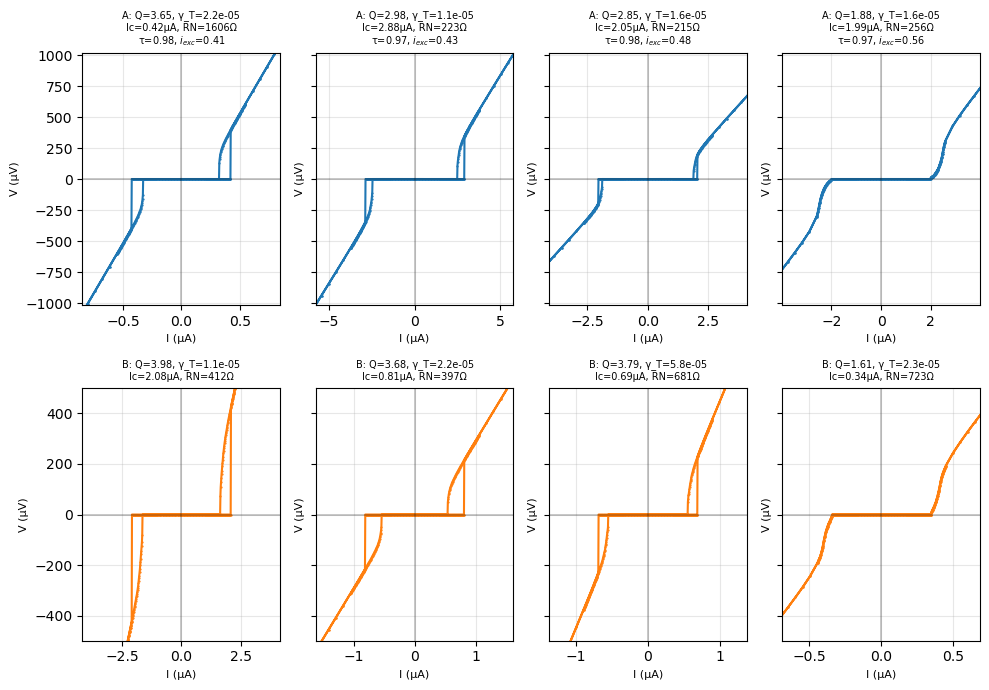

In [23]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path

data = np.load(Path.cwd() / "iv_dataset.npz", allow_pickle=False)
I, V, y, params = data["I"], data["V"], data["y"], data["params"]
CLASS_NAMES = [str(s) for s in data["class_names"]]
SHORT = ['A', 'B']

fig, axes = plt.subplots(2,   4, figsize=(10, 7), sharey='row')
for cls_idx in range(4):
    idxs = np.where(y == cls_idx)[0][:4]
    for col, idx in enumerate(idxs):
        ax = axes[cls_idx, col]
        color = 'tab:blue' if cls_idx == 0 else 'tab:orange'
        ax.plot(I[idx], V[idx], '.', markersize=1.2, linestyle='-', color=color)
        ax.axhline(0, color='k', lw=0.3); ax.axvline(0, color='k', lw=0.3)
        ax.grid(alpha=0.3)
        axis_scale = 2
        ax.set_xlim(-axis_scale*params['Ic_uA'][idx], axis_scale*params['Ic_uA'][idx])
        ax.set_ylim(-axis_scale*params['Ic_uA'][idx]*params['RN_Ohm'][idx], axis_scale*params['Ic_uA'][idx]*params['RN_Ohm'][idx])
        p = params[idx]
        title = (f"{SHORT[cls_idx]}: Q={p['Q']:.2f}, γ_T={p['gamma_T']:.1e}\n"
                 f"Ic={p['Ic_uA']:.2f}µA, RN={p['RN_Ohm']:.0f}Ω")
        if p['cpr'] == 1:
            title += f"\nτ={p['cpr_p']:.2f}, $i_{{exc}}$={p['i_exc']:.2f}"
        ax.set_title(title, fontsize=7)
        ax.set_xlabel("I (µA)", fontsize=8)
        ax.set_ylabel("V (µV)", fontsize=8)
plt.tight_layout()
plt.savefig("../Fig/Fig2_example_traces.png", dpi=300)
plt.show()

loaded 20000 traces of length 801, 2 classes
PCA explained variance (PC1, PC2): [0.847 0.088]
Running t-SNE on 5000 samples...


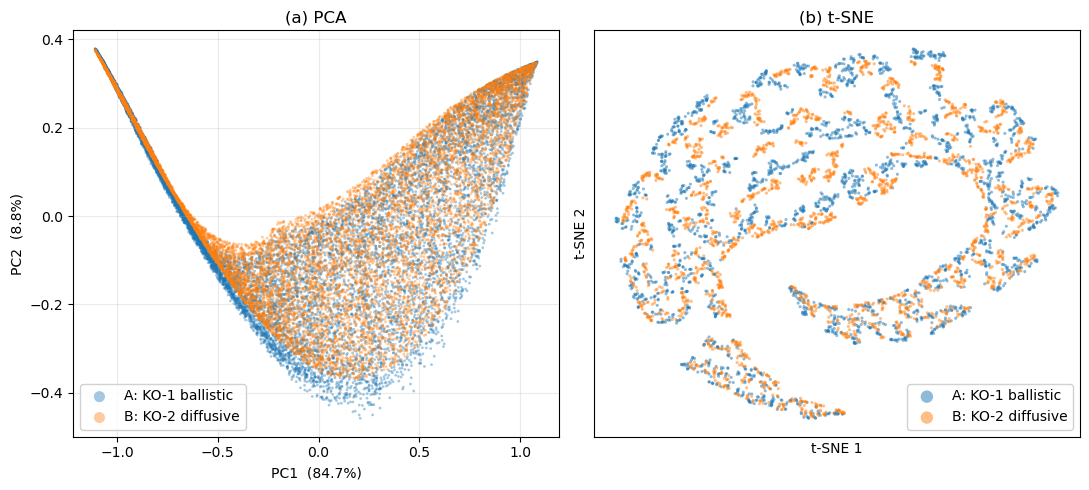


Saved -> c:\Users\Frederik\Python\ML4P\Final Project\s_bal_difussive_high_tau_project\..\Fig\Fig3_dimensionality_reduction.png + .pdf


In [14]:
"""
Figure 2: Dimensionality reduction of the IV-curve dataset.

Two subplots: PCA (left) and t-SNE (right) on self-normalized traces,
colored by class label.
"""
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()


# ----- Load -----
data = np.load(HERE / "iv_dataset.npz", allow_pickle=False)
V = data["V"]
y = data["y"]
class_names = [str(s) for s in data["class_names"]]
N, M = V.shape
n_classes = len(class_names)
print(f"loaded {N} traces of length {M}, {n_classes} classes")


# ----- Self-normalize (per-trace peak) -----
V_max  = np.maximum(np.abs(V).max(axis=1, keepdims=True), 1e-9)
V_self = V / V_max


# ----- PCA on the full dataset -----
pca = PCA(n_components=2, random_state=0).fit(V_self)
X_pca = pca.transform(V_self)
print(f"PCA explained variance (PC1, PC2): "
      f"{pca.explained_variance_ratio_[:2].round(3)}")


# ----- t-SNE on a subsample -----
SUB_N = min(5000, N)
rng = np.random.default_rng(0)
sub_idx = rng.choice(N, size=SUB_N, replace=False)
y_sub = y[sub_idx]

print(f"Running t-SNE on {SUB_N} samples...")
X_tsne = TSNE(n_components=2, perplexity=30, init='pca',
              random_state=0, learning_rate='auto').fit_transform(V_self[sub_idx])


# ----- Plot -----
COLORS = {0: 'tab:blue', 1: 'tab:orange'}
LABELS = {0: 'A: KO-1 ballistic', 1: 'B: KO-2 diffusive'}

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# (a) PCA
ax = axes[0]
for cls_idx in range(n_classes):
    m = (y == cls_idx)
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=4, alpha=0.4,
               c=COLORS[cls_idx], label=LABELS[cls_idx],
               edgecolors='none')
ax.set_xlabel(f"PC1  ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2  ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_title("(a) PCA")
ax.legend(markerscale=4, fontsize=10, loc='best', framealpha=0.9)
ax.grid(alpha=0.25)

# (b) t-SNE
ax = axes[1]
for cls_idx in range(n_classes):
    m = (y_sub == cls_idx)
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1], s=5, alpha=0.5,
               c=COLORS[cls_idx], label=LABELS[cls_idx],
               edgecolors='none')
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("(b) t-SNE")
ax.legend(markerscale=4, fontsize=10, loc='best', framealpha=0.9)
ax.grid(alpha=0.25)
ax.set_xticks([]); ax.set_yticks([])

fig.tight_layout()
fig.savefig(HERE / "fig_dimreduction.png", dpi=200, bbox_inches='tight')
fig.savefig(HERE / "fig_dimreduction.pdf", bbox_inches='tight')
plt.savefig(HERE / "../Fig/Fig3_dimensionality_reduction.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved -> {HERE / '../Fig/Fig3_dimensionality_reduction.png'} + .pdf")

In [29]:
"""
Cell 1: feature extraction.

Extract the FIVE classical IV-curve features for each trace:
    [I_sw, I_R, R_N, I_exc, hysteresis_ratio]

The hysteresis ratio I_R / I_sw is the new entry. It directly probes
the depth and shape of the tilted-washboard potential and is
CPR-dependent at fixed Q. For the sinusoidal CPR in the underdamped
limit, Stewart-McCumber gives I_R/I_sw ~ 4/(piQ); for the skewed KO
CPRs the same Q produces a different ratio because the washboard
wells are deeper relative to the saddle. Including this feature lets
the classical baseline access CPR-shape information through the
retrapping dynamics.

Output: iv_features.npz with keys
    X     (N, 5)  float32   features
    y     (N,)    int64
    feat_names    list of names
"""
import time
from pathlib import Path
import numpy as np
from scipy.stats import mannwhitneyu

try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()


# ----- 1. Load -----
data = np.load(HERE / "iv_dataset.npz", allow_pickle=False)
I        = data["I"]
V        = data["V"]
y        = data["y"]
params   = data["params"]
sweep_dl = data["sweep_dimless"]
class_names = [str(s) for s in data["class_names"]]
N, M = V.shape
n_classes = len(class_names)
print(f"loaded {N} traces of length {M}, {n_classes} classes:")
for c, name in enumerate(class_names):
    print(f"  {c}: {name}  ({(y == c).sum()} traces)")


# ----- 2. Sweep legs -----
diffs = np.diff(sweep_dl)
turning = np.where(np.diff(np.sign(diffs)) != 0)[0] + 1
assert len(turning) == 2, f"expected 2 reversals, got {len(turning)}"
leg1_end, leg2_end = turning[0], turning[1]
print(f"  leg1 (0 -> +i_max):     {leg1_end+1} points")
print(f"  leg2 (+i_max -> -i_max): {leg2_end-leg1_end+1} points")
print(f"  leg3 (-i_max -> 0):     {M-leg2_end} points")


# ----- 3. Feature extraction -----
def fit_branch(I_branch, V_branch, I_lo_thr):
    """Linear fit on resistive part of one polarity branch."""
    mask = np.abs(I_branch) > I_lo_thr
    if mask.sum() < 3:
        return None, None
    slope, intercept = np.polyfit(I_branch[mask], V_branch[mask], 1)
    return float(slope), float(intercept)


def extract_features_one(I_trace, V_trace, leg1_end, leg2_end):
    """Extract (I_sw, I_R, R_N, I_exc, hysteresis_ratio) from one trace."""
    M = I_trace.shape[0]

    # Per-trace voltage threshold from quiet supercurrent region
    center_idx = np.argsort(np.abs(I_trace))[: max(5, M // 20)]
    v_center = V_trace[center_idx]
    mad = np.median(np.abs(v_center - np.median(v_center)))
    v_thr = max(5.0 * 1.4826 * mad, 1.0)
    above = np.abs(V_trace) > v_thr

    # leg1 (V=0 -> V>0 at +I_sw)
    leg1_above = above[:leg1_end + 1]
    if leg1_above.any():
        I_sw_pos = abs(I_trace[np.argmax(leg1_above)])
    else:
        I_sw_pos = np.nan

    # leg2 positive half (V>0 -> V=0 at +I_R)
    leg2_idx = np.arange(leg1_end, leg2_end + 1)
    pos_in_leg2 = leg2_idx[I_trace[leg2_idx] > 0]
    above_in_pos = above[pos_in_leg2]
    if above_in_pos.any():
        last_above_local = len(above_in_pos) - 1 - np.argmax(above_in_pos[::-1])
        I_R_pos = abs(I_trace[pos_in_leg2[last_above_local]])
    else:
        I_R_pos = I_sw_pos

    # leg2 negative half (V=0 -> V<0 at -I_sw)
    neg_in_leg2 = leg2_idx[I_trace[leg2_idx] < 0]
    above_in_neg = above[neg_in_leg2]
    if above_in_neg.any():
        I_sw_neg = abs(I_trace[neg_in_leg2[np.argmax(above_in_neg)]])
    else:
        I_sw_neg = np.nan

    # leg3 (V<0 -> V=0 at -I_R)
    leg3_above = above[leg2_end:]
    if leg3_above.any():
        last_above_local = len(leg3_above) - 1 - np.argmax(leg3_above[::-1])
        I_R_neg = abs(I_trace[leg2_end + last_above_local])
    else:
        I_R_neg = I_sw_neg if not np.isnan(I_sw_neg) else I_sw_pos

    sw_vals = [v for v in (I_sw_pos, I_sw_neg) if not np.isnan(v)]
    R_vals  = [v for v in (I_R_pos,  I_R_neg)  if not np.isnan(v)]
    I_sw = np.mean(sw_vals) if sw_vals else 0.0
    I_R  = np.mean(R_vals)  if R_vals  else I_sw

    # Per-branch fit for I_exc (no symmetry cancellation)
    I_lo = 1.3 * max(I_sw, 1e-6)
    I_pos = I_trace[:leg1_end + 1]; V_pos = V_trace[:leg1_end + 1]
    s_pos, b_pos = fit_branch(I_pos, V_pos, I_lo)
    I_neg = I_trace[leg2_end:];     V_neg = V_trace[leg2_end:]
    s_neg, b_neg = fit_branch(I_neg, V_neg, I_lo)

    slopes = [s for s in (s_pos, s_neg) if s is not None]
    if not slopes:
        n_fit = max(3, M // 5)
        idx = np.argsort(np.abs(I_trace))[-n_fit:]
        s_fb, b_fb = np.polyfit(I_trace[idx], V_trace[idx], 1)
        R_N = float(s_fb)
        I_exc = float(-b_fb / s_fb) if abs(s_fb) > 1e-9 else 0.0
    else:
        R_N = float(np.mean(slopes))
        iexc_estimates = []
        if s_pos is not None and abs(s_pos) > 1e-9:
            iexc_estimates.append(-b_pos / s_pos)
        if s_neg is not None and abs(s_neg) > 1e-9:
            iexc_estimates.append(+b_neg / s_neg)
        I_exc = float(np.mean(iexc_estimates)) if iexc_estimates else 0.0

    # Hysteresis ratio: I_R / I_sw, clipped to [0, 1]
    if I_sw > 1e-6:
        hyst_ratio = I_R / I_sw
        hyst_ratio = np.clip(hyst_ratio, 0.0, 1.0)
    else:
        hyst_ratio = 1.0

    return I_sw, I_R, float(R_N), I_exc, float(hyst_ratio)


# ----- 4. Run -----
print("\nExtracting features (5 features per trace)...")
t0 = time.time()
features = np.empty((N, 5), dtype=np.float32)
for k in range(N):
    features[k] = extract_features_one(I[k], V[k], leg1_end, leg2_end)
    if (k + 1) % 5000 == 0:
        print(f"  {k+1}/{N} ({time.time()-t0:.1f}s)")
print(f"Total: {time.time()-t0:.1f}s")


# ----- 5. Save -----
np.savez_compressed(
    HERE / "iv_features.npz",
    X=features,
    y=y,
    feat_names=np.array(["I_sw_uA", "I_R_uA", "R_N_Ohm", "Iexc_uA",
                          "hyst_ratio"]),
    class_names=data["class_names"],
)
print(f"Saved -> {HERE / 'iv_features.npz'}")


# ----- 6. Per-class summary -----
print("\nFeature summary per class (median ± MAD):")
header = f"{'feature':<14s}  " + "  ".join(
    f"{name[:10]:<13s}" for name in class_names)
print(header)
for j, name in enumerate(["I_sw [uA]", "I_R [uA]", "R_N [Ohm]",
                           "Iexc [uA]", "I_R/I_sw"]):
    line = f"{name:<14s}  "
    for c in range(n_classes):
        f = features[y == c, j]
        med = np.median(f)
        mad = np.median(np.abs(f - med))
        line += f"{med:7.3f}±{mad:5.3f}    "
    print(line)


# ----- 7. Class separability -----
print("\nFeature class-separability (Mann-Whitney U, |rank-biserial|):")
print("  Closer to 0 = features are statistically indistinguishable.")
for j, name in enumerate(["I_sw_uA", "I_R_uA", "R_N_Ohm",
                           "Iexc_uA", "hyst_ratio"]):
    a = features[y == 0, j]
    b = features[y == 1, j]
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    rb = 2.0 * U / (len(a) * len(b)) - 1.0
    flag = "  <-- SIGNAL" if abs(rb) > 0.05 else ""
    print(f"  {name:<12s}: rank-biserial = {abs(rb):+.4f}, p = {p:.2e}{flag}")

loaded 20000 traces of length 801, 2 classes:
  0: A_short_ballistic_KO1  (10000 traces)
  1: B_short_diffusive_KO2  (10000 traces)
  leg1 (0 -> +i_max):     201 points
  leg2 (+i_max -> -i_max): 401 points
  leg3 (-i_max -> 0):     201 points

Extracting features (5 features per trace)...
  5000/20000 (1.6s)
  10000/20000 (3.1s)
  15000/20000 (4.7s)
  20000/20000 (6.3s)
Total: 6.3s
Saved -> c:\Users\Frederik\Python\ML4P\Final Project\iv_features.npz

Feature summary per class (median ± MAD):
feature         A_short_ba     B_short_di   
I_sw [uA]         0.933±0.482      0.950±0.491    
I_R [uA]          0.873±0.450      0.862±0.446    
R_N [Ohm]       520.689±290.067    377.801±209.958    
Iexc [uA]         0.464±0.240      0.467±0.242    
I_R/I_sw          0.988±0.012      0.953±0.047    

Feature class-separability (Mann-Whitney U, |rank-biserial|):
  Closer to 0 = features are statistically indistinguishable.
  I_sw_uA     : rank-biserial = +0.0013, p = 8.75e-01
  I_R_uA      : ran

loaded features: (20000, 5), 2 classes:
  0 (A): A_short_ballistic_KO1  (10000 samples)
  1 (B): B_short_diffusive_KO2  (10000 samples)

split: train=14000  val=3000  test=3000

--- Logistic Regression ---
  trained in 0.01s
  val acc:  0.600
  test acc: 0.590
  test ROC-AUC: 0.636

  classification report:
              precision    recall  f1-score   support

           A      0.600     0.539     0.568      1500
           B      0.581     0.640     0.609      1500

    accuracy                          0.590      3000
   macro avg      0.591     0.590     0.589      3000
weighted avg      0.591     0.590     0.589      3000


--- Random Forest ---
  trained in 2.12s
  val acc:  0.612
  test acc: 0.622
  test ROC-AUC: 0.667

  classification report:
              precision    recall  f1-score   support

           A      0.624     0.611     0.618      1500
           B      0.619     0.632     0.626      1500

    accuracy                          0.622      3000
   macro avg      0.

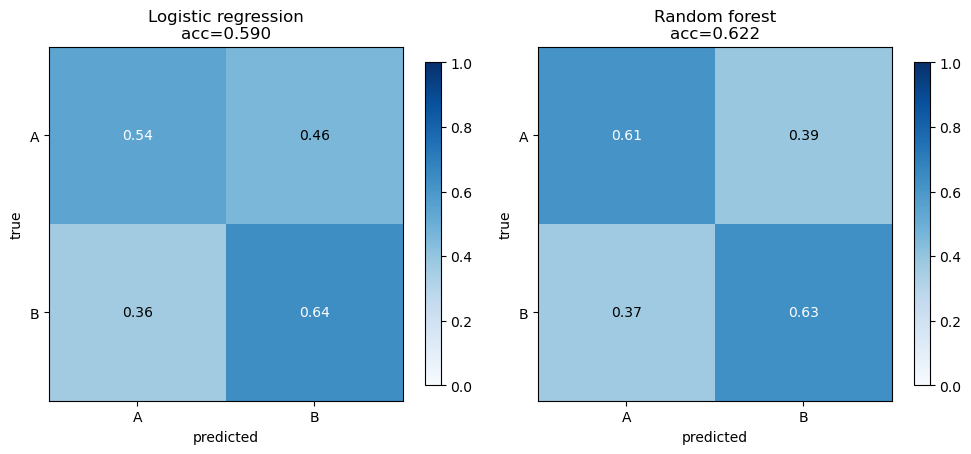

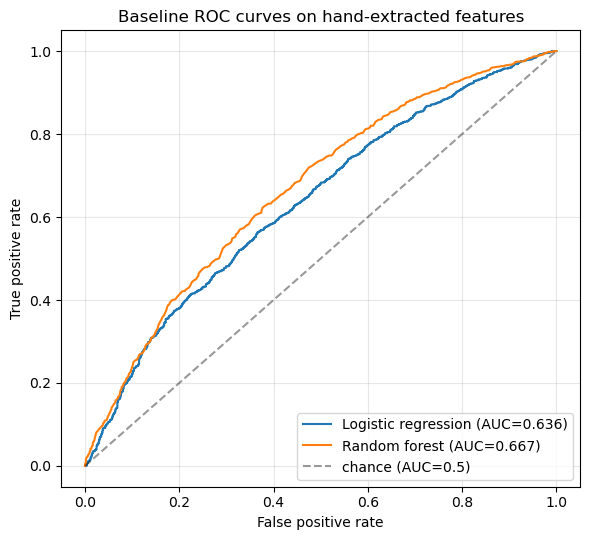


--- 5-fold cross-validation (stratified, on full dataset) ---
  Logistic regression: 0.607 ± 0.004
  Random forest:       0.621 ± 0.001
  (chance = 0.5)

Saved -> c:\Users\Frederik\Python\ML4P\Final Project\s_bal_difussive_high_tau_project\baseline_predictions.npz


In [20]:
"""
Cell 2: train and evaluate classical baselines.

Two baselines on the     four classical features:
  1. Logistic regression (linear, fast, gives a sanity-check accuracy).
  2. Random forest (nonlinear, more flexible).

In this 2-class dataset, the four features are designed to be nearly
identical between the two classes -- so we expect both baselines to
perform near chance (~50%).  Significantly above 50% would indicate a
leak in the dataset design (some feature still carries class info).
Significantly below 50% would also be a problem.

A 50% baseline is the right outcome and motivates the CNN: it must do
better by using raw-curve shape, since the four features are exhausted.
"""
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score)

try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()

# ----- 1. Load features -----
data = np.load(HERE / "iv_features.npz", allow_pickle=False)
X = data["X"].astype(np.float32)
y = data["y"].astype(np.int64)
feat_names  = [str(s) for s in data["feat_names"]]
class_names = [str(s) for s in data["class_names"]]
n_classes   = len(class_names)
SHORT = ['A', 'B']
print(f"loaded features: {X.shape}, {n_classes} classes:")
for c, name in enumerate(class_names):
    print(f"  {c} ({SHORT[c]}): {name}  ({(y == c).sum()} samples)")


# ----- 2. Stratified split: 70 / 15 / 15 -----
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=0)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=0)
print(f"\nsplit: train={len(y_tr)}  val={len(y_val)}  test={len(y_te)}")


# ----- 3. Standardize features -----
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_val_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_val), scaler.transform(X_te)


# ----- 4. Logistic regression -----
print("\n--- Logistic Regression ---")
t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=0).fit(X_tr_s, y_tr)
lr_pred_val  = lr.predict(X_val_s)
lr_prob_test = lr.predict_proba(X_te_s)[:, 1]
lr_pred_test = lr.predict(X_te_s)
print(f"  trained in {time.time()-t0:.2f}s")
print(f"  val acc:  {accuracy_score(y_val, lr_pred_val):.3f}")
print(f"  test acc: {accuracy_score(y_te, lr_pred_test):.3f}")
print(f"  test ROC-AUC: {roc_auc_score(y_te, lr_prob_test):.3f}")
print("\n  classification report:")
print(classification_report(y_te, lr_pred_test,
                              target_names=SHORT, digits=3))


# ----- 5. Random forest -----
print("\n--- Random Forest ---")
t0 = time.time()
rf = RandomForestClassifier(n_estimators=400, max_depth=None,
                              random_state=0, n_jobs=-1).fit(X_tr, y_tr)
rf_pred_val  = rf.predict(X_val)
rf_prob_test = rf.predict_proba(X_te)[:, 1]
rf_pred_test = rf.predict(X_te)
print(f"  trained in {time.time()-t0:.2f}s")
print(f"  val acc:  {accuracy_score(y_val, rf_pred_val):.3f}")
print(f"  test acc: {accuracy_score(y_te, rf_pred_test):.3f}")
print(f"  test ROC-AUC: {roc_auc_score(y_te, rf_prob_test):.3f}")
print("\n  classification report:")
print(classification_report(y_te, rf_pred_test,
                              target_names=SHORT, digits=3))

# Feature importance (RF)
imp = rf.feature_importances_
print("\n  RF feature importance:")
for name, w in sorted(zip(feat_names, imp), key=lambda kv: -kv[1]):
    print(f"    {name:<12s}: {w:.3f}")


# ----- 6. Confusion matrices side-by-side -----
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, preds, label in [(axes[0], lr_pred_test, 'Logistic regression'),
                          (axes[1], rf_pred_test, 'Random forest')]:
    cm = confusion_matrix(y_te, preds, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha='center', va='center',
                    color='white' if cm[i, j] > 0.5 else 'black')
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(SHORT); ax.set_yticklabels(SHORT)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{label}\nacc={accuracy_score(y_te, preds):.3f}")
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(HERE / "../Fig/baseline_confusion.png", dpi=130, bbox_inches='tight')
plt.show()


# ----- 7. ROC curves (binary task, one curve per model) -----
from sklearn.metrics import roc_curve
fig, ax = plt.subplots(figsize=(6, 5.5))
for prob, name, color in [(lr_prob_test, 'Logistic regression', 'tab:blue'),
                           (rf_prob_test, 'Random forest',       'tab:orange')]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc = roc_auc_score(y_te, prob)
    ax.plot(fpr, tpr, '-', color=color,
            label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='chance (AUC=0.5)')
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Baseline ROC curves on hand-extracted features")
ax.grid(alpha=0.3); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(HERE / "baseline_roc.png", dpi=130, bbox_inches='tight')
plt.show()


# ----- 8. Cross-validation (stratified 5-fold) for robust CI -----
print("\n--- 5-fold cross-validation (stratified, on full dataset) ---")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
lr_accs, rf_accs = [], []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
    X_tr_f, X_te_f, y_tr_f, y_te_f = X[tr_idx], X[te_idx], y[tr_idx], y[te_idx]
    sc = StandardScaler().fit(X_tr_f)
    lr_f = LogisticRegression(max_iter=1000, random_state=0).fit(
        sc.transform(X_tr_f), y_tr_f)
    rf_f = RandomForestClassifier(n_estimators=400, random_state=0,
                                    n_jobs=-1).fit(X_tr_f, y_tr_f)
    lr_accs.append(accuracy_score(y_te_f, lr_f.predict(sc.transform(X_te_f))))
    rf_accs.append(accuracy_score(y_te_f, rf_f.predict(X_te_f)))
print(f"  Logistic regression: {np.mean(lr_accs):.3f} ± {np.std(lr_accs):.3f}")
print(f"  Random forest:       {np.mean(rf_accs):.3f} ± {np.std(rf_accs):.3f}")
print(f"  (chance = 0.5)")


# ----- 9. Save predictions for later analysis -----
np.savez(HERE / "baseline_predictions.npz",
         lr_prob_test=lr_prob_test, lr_pred_test=lr_pred_test,
         rf_prob_test=rf_prob_test, rf_pred_test=rf_pred_test,
         y_test=y_te, X_test=X_te,
         lr_cv_accs=lr_accs, rf_cv_accs=rf_accs)
print(f"\nSaved -> {HERE / 'baseline_predictions.npz'}")

In [34]:
"""
Cell 3: train a 1D CNN on the IV-curve dataset (KO-1 vs KO-2 binary task).

Inputs : per-trace V signal, peak-normalized so |V|_max = 1.
Output : 2-class softmax over {A=KO-1 ballistic, B=KO-2 diffusive}.

Architecture: 4 conv blocks + global average pool + linear head, ~70k params.

Per-trace peak normalization removes the (I_c, R_N) physical scale, leaving
only the shape information -- the CPR-shape signature is the only real
discriminator we left in the dataset.
"""
import time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

# ----- 1. Load and prepare data -----
data = np.load(HERE / "iv_dataset.npz", allow_pickle=False)
V = data["V"].astype(np.float32)
y = data["y"].astype(np.int64)
class_names = [str(s) for s in data["class_names"]]
n_classes = len(class_names)
N, M = V.shape
print(f"data: {N} traces of length {M}, {n_classes} classes:")
for c, name in enumerate(class_names):
    print(f"  {c}: {name}  ({(y == c).sum()} traces)")

V_mean_global = V.mean()
V_std_global = V.std()
X = ((V - V_mean_global) / V_std_global).astype(np.float32)
X = X[:, np.newaxis, :]

# Same 70/15/15 split as the baseline (matched random_state)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=0)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=0)
print(f"\n  train={len(y_tr)}  val={len(y_val)}  test={len(y_te)}")


# ----- 2. Augmentation -----
class IVDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
        self.augment = augment
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            # Modest noise (~1% of post-normalization scale)
            x = x + 0.01 * torch.randn_like(x)
            # Random shift up to +/- 2 sweep points
            shift = torch.randint(-2, 3, (1,)).item()
            if shift != 0:
                x = torch.roll(x, shifts=shift, dims=-1)
            # Small multiplicative scaling
            x = x * (1.0 + 0.05 * (torch.rand(1).item() - 0.5) * 2)
            # Sign flip (the physics is symmetric in I -> -I, V -> -V)
            if torch.rand(1).item() < 0.5:
                x = -x
        return x, self.y[idx]

train_ds = IVDataset(X_tr, y_tr, augment=True)
val_ds   = IVDataset(X_val, y_val, augment=False)
test_ds  = IVDataset(X_te,  y_te,  augment=False)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=0)


# ----- 3. Model -----
class IVCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, kernel_size=7, padding=3, stride=2),
                nn.BatchNorm1d(c_out,momentum=0.01),
                nn.GELU(),
                nn.Dropout(0.1),
            )
        self.net = nn.Sequential(
            block(1,  16),
            block(16, 32),
            block(32, 64),
            block(64, 64),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(64, n_classes)
    def forward(self, x):
        h = self.net(x)
        h = self.pool(h).squeeze(-1)
        return self.head(h)


model = IVCNN(n_classes=n_classes).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nmodel: IVCNN with {n_params:,} parameters")


# ----- 4. Training loop -----
EPOCHS = 25
LR = 3e-3
WD = 1e-4

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)


def evaluate(dl):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y_b in dl:
            x, y_b = x.to(device), y_b.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y_b, reduction='sum')
            loss_sum += loss.item()
            correct += (logits.argmax(-1) == y_b).sum().item()
            total += len(y_b)
    return correct / total, loss_sum / total


print("\nstarting training...")
best_val_acc = 0.0
history = {'tr_loss': [], 'val_loss': [], 'val_acc': []}

t0 = time.time()
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    n_seen = 0
    for x, y_b in train_dl:
        x, y_b = x.to(device), y_b.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y_b)
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_loss += loss.item() * len(y_b)
        n_seen += len(y_b)
    sched.step()

    val_acc, val_loss = evaluate(val_dl)
    history['tr_loss'].append(epoch_loss / n_seen)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), HERE / "iv_cnn_best.pt")
    
    print(f"  epoch {epoch+1:2d}/{EPOCHS}  "
          f"train_loss={epoch_loss/n_seen:.3f}  "
          f"val_loss={val_loss:.3f}  val_acc={val_acc:.3f}  "
          f"lr={sched.get_last_lr()[0]:.4f}")

# AFTER the loop ends -- single BN re-estimation pass
print(f"\ndone in {time.time()-t0:.1f}s.  best val acc = {best_val_acc:.3f}")

# === BN re-estimation on the best checkpoint ===
print("\nRe-estimating BatchNorm running stats on clean training data...")
# Load the best-val checkpoint (might not be the model's current state)
model.load_state_dict(torch.load(HERE / "iv_cnn_best.pt", map_location=device))
# Pass clean (un-augmented) training data through in train mode
model.train()
with torch.no_grad():
    eval_dl = DataLoader(IVDataset(X_tr, y_tr, augment=False),
                          batch_size=256, shuffle=True)
    for x, _ in eval_dl:
        _ = model(x.to(device))
model.eval()
# Save the updated checkpoint
torch.save(model.state_dict(), HERE / "iv_cnn_best.pt")
print("BN stats re-estimated and checkpoint updated.")

np.savez(HERE / "iv_cnn_history.npz", **history)


using device: cuda
data: 20000 traces of length 801, 2 classes:
  0: A_short_ballistic_KO1  (10000 traces)
  1: B_short_diffusive_KO2  (10000 traces)

  train=14000  val=3000  test=3000

model: IVCNN with 47,362 parameters

starting training...
  epoch  1/25  train_loss=0.650  val_loss=0.772  val_acc=0.585  lr=0.0030
  epoch  2/25  train_loss=0.649  val_loss=0.680  val_acc=0.614  lr=0.0030
  epoch  3/25  train_loss=0.647  val_loss=0.662  val_acc=0.599  lr=0.0029
  epoch  4/25  train_loss=0.645  val_loss=0.759  val_acc=0.543  lr=0.0028
  epoch  5/25  train_loss=0.643  val_loss=0.787  val_acc=0.534  lr=0.0027
  epoch  6/25  train_loss=0.642  val_loss=1.358  val_acc=0.508  lr=0.0026
  epoch  7/25  train_loss=0.640  val_loss=0.994  val_acc=0.533  lr=0.0025
  epoch  8/25  train_loss=0.635  val_loss=2.063  val_acc=0.500  lr=0.0023
  epoch  9/25  train_loss=0.628  val_loss=1.995  val_acc=0.501  lr=0.0021
  epoch 10/25  train_loss=0.614  val_loss=0.778  val_acc=0.543  lr=0.0020
  epoch 11/25  

C:\Users\Frederik\AppData\Local\Temp\ipykernel_21608\966902563.py:179: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(HERE / "iv_cnn_best.pt"

BN stats re-estimated and checkpoint updated.


using device: cuda


C:\Users\Frederik\AppData\Local\Temp\ipykernel_12376\3413082169.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(HERE / "iv_cnn_best.pt"

loaded best CNN checkpoint
Optimal val-set threshold: 0.90 (val acc = 0.738)

=== CNN test results (threshold-tuned) ===
  test accuracy: 0.743
  test ROC-AUC:  0.781

  classification report:
              precision    recall  f1-score   support

           A      0.757     0.717     0.736      1500
           B      0.731     0.769     0.750      1500

    accuracy                          0.743      3000
   macro avg      0.744     0.743     0.743      3000
weighted avg      0.744     0.743     0.743      3000


=== Head-to-head ===
  Logistic regression: acc = 0.590, AUC = 0.636
  Random forest:       acc = 0.622, AUC = 0.667
  CNN (raw curve):     acc = 0.743, AUC = 0.781
  CNN advantage over RF baseline: +12.2 pp accuracy, +0.114 AUC


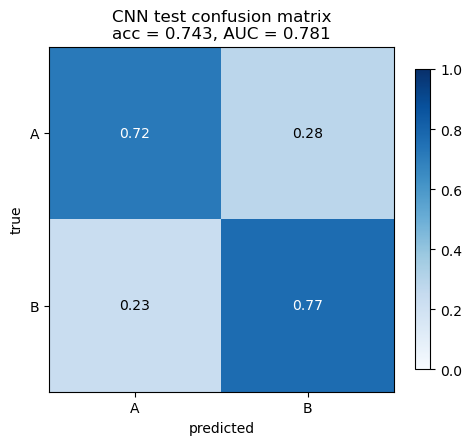

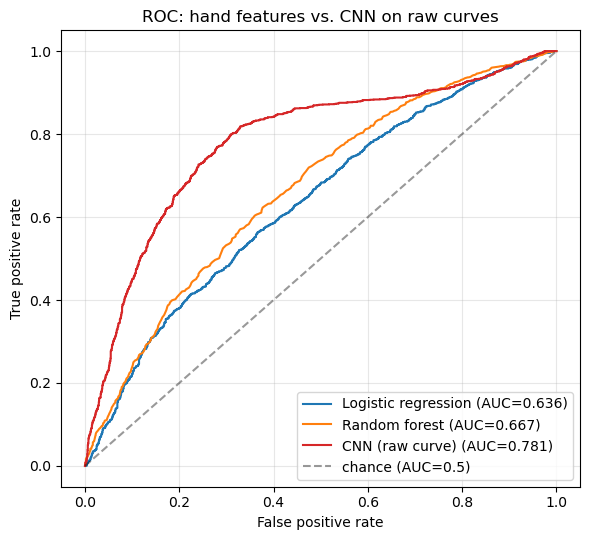


=== Calibration via temperature scaling ===
  optimal temperature: T = 4.883


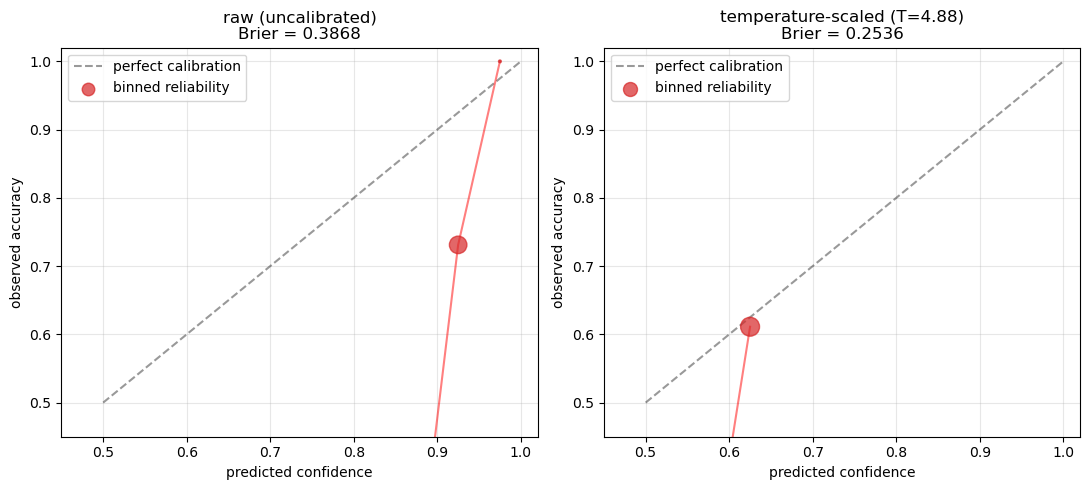

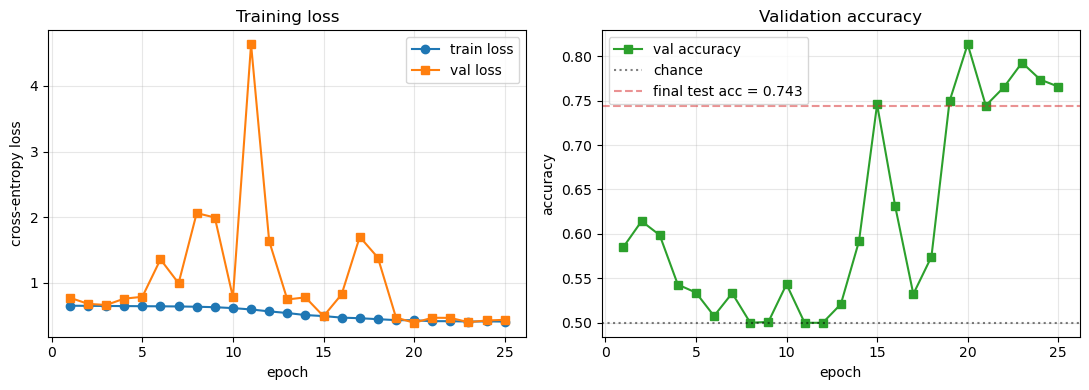


=== Error analysis: accuracy vs. physical parameters ===


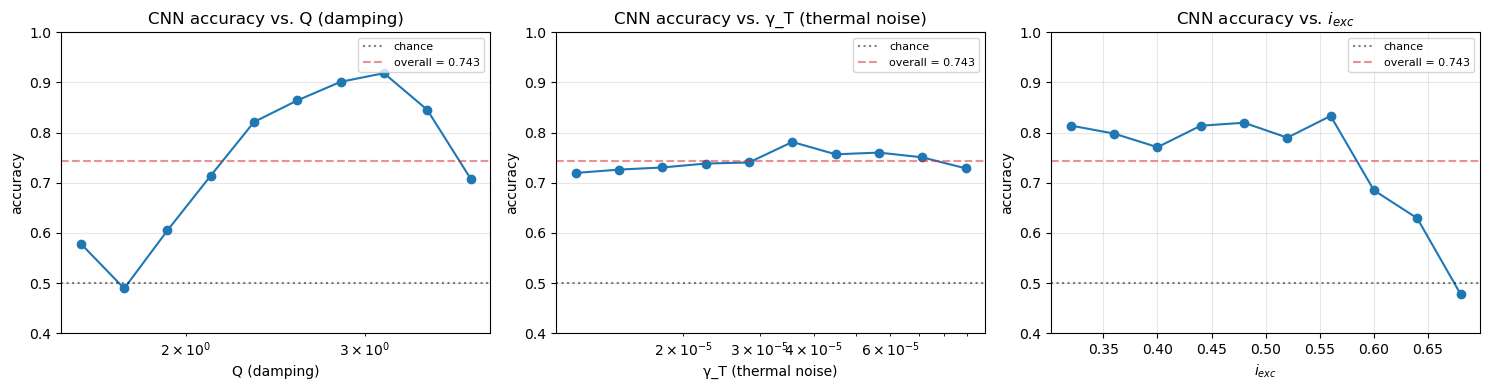


Saved -> c:\Users\Frederik\Python\ML4P\Final Project\s_bal_difussive_high_tau_project\cnn_test_predictions.npz

SUMMARY
  Logistic regression: acc = 0.590, AUC = 0.636
  Random forest:       acc = 0.622, AUC = 0.667
  CNN (raw curve):     acc = 0.743, AUC = 0.781
  Calibration: T_opt = 4.883


In [16]:
"""
Cell 4: evaluate the trained CNN, with calibration and head-to-head
comparison against the classical baselines.

Outputs:
  - test accuracy / ROC-AUC, with comparison to LR and RF baselines
  - confusion matrix
  - reliability (calibration) diagram with temperature scaling
  - training-curve plot
  - error analysis: are CNN errors correlated with physical parameters?
"""
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_curve,
                              roc_auc_score, brier_score_loss)

try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")


# ----- 1. Reload data with the same split -----
data = np.load(HERE / "iv_dataset.npz", allow_pickle=False)
V = data["V"].astype(np.float32)
y = data["y"].astype(np.int64)
params = data["params"]
class_names = [str(s) for s in data["class_names"]]
SHORT = ['A', 'B']
n_classes = len(class_names)
N, M = V.shape

V_max = np.maximum(np.abs(V).max(axis=1, keepdims=True), 1e-9)
X = (V / V_max).astype(np.float32)
X = X[:, np.newaxis, :]

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=0)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=0)
# Indices into the original dataset for the test set, so we can pull params
idx_all = np.arange(len(y))
idx_tr_arr, idx_tmp_arr = train_test_split(
    idx_all, test_size=0.30, stratify=y, random_state=0)
idx_val_arr, idx_te_arr = train_test_split(
    idx_tmp_arr, test_size=0.50, stratify=y[idx_tmp_arr], random_state=0)
params_te = params[idx_te_arr]


# ----- 2. Reload model -----
class IVCNN(torch.nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        def block(c_in, c_out):
            return torch.nn.Sequential(
                torch.nn.Conv1d(c_in, c_out, 7, padding=3, stride=2),
                torch.nn.BatchNorm1d(c_out),
                torch.nn.GELU(),
                torch.nn.Dropout(0.1),
            )
        self.net = torch.nn.Sequential(
            block(1, 16), block(16, 32), block(32, 64), block(64, 64))
        self.pool = torch.nn.AdaptiveAvgPool1d(1)
        self.head = torch.nn.Linear(64, n_classes)
    def forward(self, x):
        h = self.net(x); h = self.pool(h).squeeze(-1); return self.head(h)


model = IVCNN(n_classes=n_classes).to(device)
model.load_state_dict(torch.load(HERE / "iv_cnn_best.pt", map_location=device))
model.eval()
print("loaded best CNN checkpoint")


def predict_logits(X_np):
    out = []
    with torch.no_grad():
        for i in range(0, len(X_np), 512):
            xb = torch.from_numpy(X_np[i:i+512]).to(device)
            out.append(model(xb).cpu().numpy())
    return np.concatenate(out)


# ----- 3. Test-set predictions -----

logits_val = predict_logits(X_val)
prob_val = torch.softmax(torch.from_numpy(logits_val), dim=1).numpy()
prob_val_B = prob_val[:, 1]   # probability of class B

# Sweep thresholds, pick the one maximizing val accuracy
from sklearn.metrics import accuracy_score
thresholds = np.linspace(0.05, 0.95, 91)
val_accs = [accuracy_score(y_val, (prob_val_B >= t).astype(int)) for t in thresholds]
best_t = thresholds[int(np.argmax(val_accs))]
print(f"Optimal val-set threshold: {best_t:.2f} (val acc = {max(val_accs):.3f})")

# Apply that threshold to test
logits_te = predict_logits(X_te)
prob_te = torch.softmax(torch.from_numpy(logits_te), dim=1).numpy()
pred_te = (prob_te[:, 1] >= best_t).astype(int)

cnn_acc = accuracy_score(y_te, pred_te)
cnn_auc = roc_auc_score(y_te, prob_te[:, 1])
print(f"\n=== CNN test results (threshold-tuned) ===")
print(f"  test accuracy: {cnn_acc:.3f}")
print(f"  test ROC-AUC:  {cnn_auc:.3f}")
print("\n  classification report:")
print(classification_report(y_te, pred_te, target_names=SHORT, digits=3))


# ----- 4. Compare to baselines -----
# Load the saved baseline predictions (Cell 2 saved these to disk).
baseline = np.load(HERE / "baseline_predictions.npz")
lr_prob_test = baseline['lr_prob_test']
lr_pred_test = baseline['lr_pred_test']
rf_prob_test = baseline['rf_prob_test']
rf_pred_test = baseline['rf_pred_test']
y_te_baseline = baseline['y_test']
# Sanity: same labels should be in both?
assert np.array_equal(y_te, y_te_baseline), \
    "test labels mismatch -- the splits in Cell 2 and Cell 3/4 must match"

lr_acc = accuracy_score(y_te, lr_pred_test)
lr_auc = roc_auc_score(y_te, lr_prob_test)
rf_acc = accuracy_score(y_te, rf_pred_test)
rf_auc = roc_auc_score(y_te, rf_prob_test)

print(f"\n=== Head-to-head ===")
print(f"  Logistic regression: acc = {lr_acc:.3f}, AUC = {lr_auc:.3f}")
print(f"  Random forest:       acc = {rf_acc:.3f}, AUC = {rf_auc:.3f}")
print(f"  CNN (raw curve):     acc = {cnn_acc:.3f}, AUC = {cnn_auc:.3f}")
print(f"  CNN advantage over RF baseline: "
      f"+{100*(cnn_acc - rf_acc):.1f} pp accuracy, "
      f"+{cnn_auc - rf_auc:.3f} AUC")


# ----- 5. Confusion matrix -----
fig, ax = plt.subplots(figsize=(5, 4.5))
cm = confusion_matrix(y_te, pred_te, normalize='true')
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, f"{cm[i,j]:.2f}", ha='center', va='center',
                color='white' if cm[i,j] > 0.5 else 'black')
ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
ax.set_xticklabels(SHORT); ax.set_yticklabels(SHORT)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"CNN test confusion matrix\nacc = {cnn_acc:.3f}, AUC = {cnn_auc:.3f}")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(HERE / "../Fig/cnn_confusion.png", dpi=130, bbox_inches='tight')
plt.show()


# ----- 6. ROC head-to-head -----
fig, ax = plt.subplots(figsize=(6, 5.5))
for prob, name, color in [(lr_prob_test, 'Logistic regression', 'tab:blue'),
                           (rf_prob_test, 'Random forest',       'tab:orange'),
                           (prob_te[:, 1], 'CNN (raw curve)',    'tab:red')]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc = roc_auc_score(y_te, prob)
    ax.plot(fpr, tpr, '-', color=color, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='chance (AUC=0.5)')
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC: hand features vs. CNN on raw curves")
ax.grid(alpha=0.3); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(HERE / "roc_comparison.png", dpi=130, bbox_inches='tight')
plt.show()


# ----- 7. Calibration: temperature scaling -----
# Fit a single scalar T on the validation set to minimize NLL,
# then evaluate calibration on the test set.
print("\n=== Calibration via temperature scaling ===")
val_logits = predict_logits(X_val)
val_logits_t = torch.from_numpy(val_logits).to(device)
y_val_t      = torch.from_numpy(y_val).to(device)

T = nn.Parameter(torch.ones(1, device=device))
opt_T = torch.optim.LBFGS([T], lr=0.1, max_iter=50)
def closure():
    opt_T.zero_grad()
    loss = F.cross_entropy(val_logits_t / T, y_val_t)
    loss.backward()
    return loss
opt_T.step(closure)
T_opt = T.item()
print(f"  optimal temperature: T = {T_opt:.3f}")

# Apply T to test logits
prob_te_cal = F.softmax(torch.from_numpy(logits_te) / T_opt, dim=1).numpy()


def reliability_curve(prob, y_true, n_bins=10):
    """Confidence-calibration curve for binary classifier."""
    confs = prob.max(axis=1)              # confidence = prob of predicted class
    preds = prob.argmax(axis=1)
    correct = (preds == y_true).astype(float)
    bins = np.linspace(0.5, 1.0, n_bins + 1)
    bin_centers, bin_acc, bin_count = [], [], []
    for i in range(n_bins):
        m = (confs >= bins[i]) & (confs < bins[i + 1])
        if i == n_bins - 1:
            m = (confs >= bins[i]) & (confs <= bins[i + 1])
        if m.sum() == 0:
            continue
        bin_centers.append(0.5 * (bins[i] + bins[i + 1]))
        bin_acc.append(correct[m].mean())
        bin_count.append(m.sum())
    return np.array(bin_centers), np.array(bin_acc), np.array(bin_count)


fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, prob_use, label in [(axes[0], prob_te,      "raw (uncalibrated)"),
                             (axes[1], prob_te_cal,  f"temperature-scaled (T={T_opt:.2f})")]:
    centers, accs, counts = reliability_curve(prob_use, y_te)
    ax.plot([0.5, 1], [0.5, 1], 'k--', alpha=0.4, label='perfect calibration')
    ax.scatter(centers, accs, s=np.sqrt(counts) * 4, c='tab:red',
               zorder=5, alpha=0.7, label='binned reliability')
    ax.plot(centers, accs, 'r-', alpha=0.5)
    brier = brier_score_loss(y_te, prob_use[:, 1])
    ax.set_xlabel("predicted confidence"); ax.set_ylabel("observed accuracy")
    ax.set_title(f"{label}\nBrier = {brier:.4f}")
    ax.set_xlim(0.45, 1.02); ax.set_ylim(0.45, 1.02)
    ax.grid(alpha=0.3); ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(HERE / "cnn_calibration.png", dpi=130, bbox_inches='tight')
plt.show()


# ----- 8. Training curves -----
hist = np.load(HERE / "iv_cnn_history.npz")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ep = np.arange(1, len(hist['tr_loss']) + 1)
axes[0].plot(ep, hist['tr_loss'], 'o-', label='train loss')
axes[0].plot(ep, hist['val_loss'], 's-', label='val loss')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('cross-entropy loss')
axes[0].grid(alpha=0.3); axes[0].legend(); axes[0].set_title("Training loss")
axes[1].plot(ep, hist['val_acc'], 's-', color='tab:green', label='val accuracy')
axes[1].axhline(0.5, color='k', linestyle=':', alpha=0.5, label='chance')
axes[1].axhline(cnn_acc, color='tab:red', linestyle='--', alpha=0.5,
                label=f'final test acc = {cnn_acc:.3f}')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].grid(alpha=0.3); axes[1].legend(); axes[1].set_title("Validation accuracy")
plt.tight_layout()
plt.savefig(HERE / "cnn_training.png", dpi=130, bbox_inches='tight')
plt.show()


# ----- 9. Error analysis: do mistakes correlate with physical params? -----
# Mistake = trace where CNN predicted wrong class.
# We bin test traces by Q, gamma_T, and i_exc and compute per-bin accuracy.
print("\n=== Error analysis: accuracy vs. physical parameters ===")
correct = (pred_te == y_te).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key, label, log in [
    (axes[0], 'Q',       'Q (damping)',          True),
    (axes[1], 'gamma_T', 'γ_T (thermal noise)', True),
    (axes[2], 'i_exc',   '$i_{exc}$',            False)]:
    vals = params_te[key]
    if log:
        bins = np.logspace(np.log10(vals.min()), np.log10(vals.max()), 11)
    else:
        bins = np.linspace(vals.min(), vals.max(), 11)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_acc, bin_n = [], []
    for i in range(len(bin_centers)):
        m = (vals >= bins[i]) & (vals < bins[i+1]) if i < len(bin_centers)-1 \
            else (vals >= bins[i]) & (vals <= bins[i+1])
        if m.sum() == 0:
            bin_acc.append(np.nan); bin_n.append(0)
        else:
            bin_acc.append(correct[m].mean())
            bin_n.append(m.sum())
    bin_acc = np.array(bin_acc); bin_n = np.array(bin_n)
    keep = bin_n > 5
    ax.plot(bin_centers[keep], bin_acc[keep], 'o-')
    ax.axhline(0.5, color='k', linestyle=':', alpha=0.5, label='chance')
    ax.axhline(cnn_acc, color='tab:red', linestyle='--', alpha=0.5,
                label=f'overall = {cnn_acc:.3f}')
    ax.set_xlabel(label); ax.set_ylabel('accuracy')
    if log:
        ax.set_xscale('log')
    ax.set_ylim(0.4, 1.0); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    ax.set_title(f"CNN accuracy vs. {label}")

plt.tight_layout()
plt.savefig(HERE / "../Fig/cnn_error_analysis.png", dpi=130, bbox_inches='tight')
plt.show()


# ----- 10. Save everything for the writeup -----
np.savez(HERE / "cnn_test_predictions.npz",
         logits=logits_te, prob_uncal=prob_te, prob_cal=prob_te_cal,
         pred=pred_te, y_test=y_te, T_opt=T_opt,
         test_acc=cnn_acc, test_auc=cnn_auc)
print(f"\nSaved -> {HERE / 'cnn_test_predictions.npz'}")

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Logistic regression: acc = {lr_acc:.3f}, AUC = {lr_auc:.3f}")
print(f"  Random forest:       acc = {rf_acc:.3f}, AUC = {rf_auc:.3f}")
print(f"  CNN (raw curve):     acc = {cnn_acc:.3f}, AUC = {cnn_auc:.3f}")
print(f"  Calibration: T_opt = {T_opt:.3f}")

using device: cuda
  train n=14000  test n=3000

  Original test I_c R_N (uV):
    class A: median =   492.4
    class B: median =   360.5
  Scrambled test I_c R_N (uV):
    class A: median =   420.4
    class B: median =   424.9

Re-extracting features on scrambled test set...
done.

Feature class-separability on SCRAMBLED test set (should be ~0 for R_N, retained for hyst_ratio):
  I_sw_uA     : rank-biserial = +0.0018, p = 9.33e-01
  I_R_uA      : rank-biserial = +0.0148, p = 4.82e-01
  R_N_Ohm     : rank-biserial = +0.0034, p = 8.72e-01
  Iexc_uA     : rank-biserial = +0.0074, p = 7.25e-01
  hyst_ratio  : rank-biserial = +0.1715, p = 1.47e-16  <-- SIGNAL


C:\Users\Frederik\AppData\Local\Temp\ipykernel_21608\838662661.py:262: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(HERE / "iv_cnn_best.pt"


OUT-OF-DISTRIBUTION SCRAMBLE TEST
method                     in-dist acc     OOD acc   in-dist AUC     OOD AUC
------------------------------------------------------------------------
Logistic regression              0.590       0.529         0.636       0.548
Random forest                    0.622       0.541         0.667       0.558
CNN (raw curve)                  0.743       0.755         0.781       0.890
------------------------------------------------------------------------
Accuracy drop                                                               
  Logistic regression: 0.061
  Random forest:       0.081
  CNN:                 -0.012
------------------------------------------------------------------------


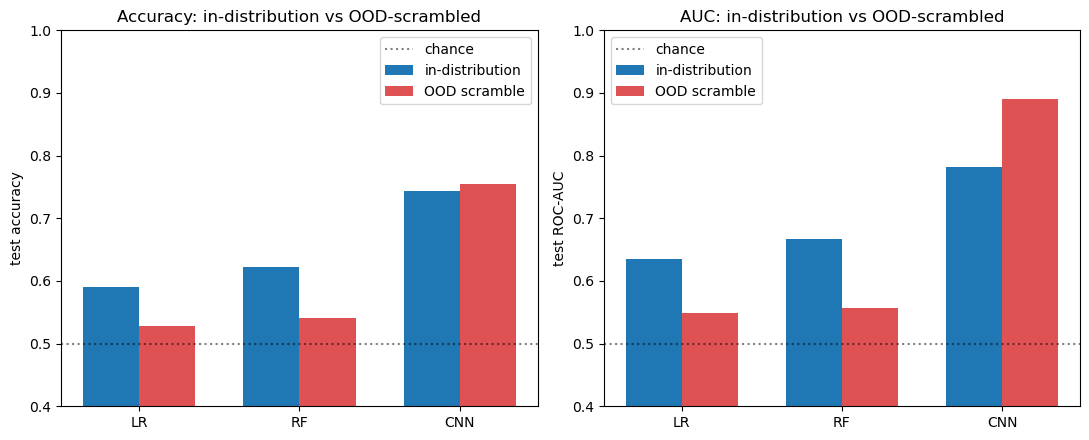


Saved -> c:\Users\Frederik\Python\ML4P\Final Project\ood_results.npz


In [36]:
"""
Cell 5: out-of-distribution scramble test.

Test whether the CNN learned CPR-shape information beyond the I_c R_N
shortcut. We rescale each test-set trace so the two classes share the
same I_c R_N distribution, breaking that feature; only true CPR-shape
information survives.

Procedure:
  1. For each test-set trace, rescale V by a factor so that the new
     I_c R_N matches a value drawn from a SHARED (class-blind) distribution.
     This preserves curve SHAPE but normalizes the absolute V scale.
  2. Re-extract hand features from the rescaled traces. The R_N feature's
     class-discriminating power should drop to ~0 (rank-biserial < 0.05).
  3. Re-evaluate hand-feature LR/RF on rescaled traces. They should drop
     close to chance (only hyst_ratio survives the scrambling).
  4. Re-evaluate CNN on the rescaled traces. CNN was trained on
     dataset-standardized curves, which means it CAN see absolute scale --
     so we apply the SAME global standardization (mean, std from training
     dataset) before feeding to the CNN.
  5. Interpretation:
       - CNN-scrambled accuracy > 0.55: CNN learned shape information
         beyond the I_c R_N shortcut. Real CPR signal recovered.
       - CNN-scrambled accuracy ~ 0.50: CNN's edge over RF was mostly from
         exploiting I_c R_N better, not new shape information.
"""
import time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")


# ----- 1. Load dataset and reproduce the same train/val/test split -----
data = np.load(HERE / "iv_dataset.npz", allow_pickle=False)
V       = data["V"].astype(np.float32)
y       = data["y"].astype(np.int64)
params  = data["params"]
class_names = [str(s) for s in data["class_names"]]
SHORT = ['A', 'B']
N, M = V.shape
sweep_dl = data["sweep_dimless"]

# Reproduce the same indices used in Cells 2/3/4
idx_all = np.arange(N)
idx_tr, idx_tmp = train_test_split(idx_all, test_size=0.30, stratify=y, random_state=0)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50, stratify=y[idx_tmp], random_state=0)

V_tr   = V[idx_tr]
V_te   = V[idx_te]
y_tr   = y[idx_tr]
y_te   = y[idx_te]
params_tr = params[idx_tr]
params_te = params[idx_te]
print(f"  train n={len(y_tr)}  test n={len(y_te)}")


# ----- 2. Build the scrambled test set -----
# Original per-trace I_c R_N
IcRN_te_orig = params_te['Ic_uA'] * params_te['RN_Ohm']  # uV

# Target distribution: shared across classes. We use the geometric mean
# of the train-set I_c R_N as the center, with the SAME log-scatter as
# present in the original dataset (so within-distribution variance is
# preserved -- only the class-mean separator is removed).
log_IcRN_tr   = np.log(params_tr['Ic_uA'] * params_tr['RN_Ohm'])
shared_log_mu = log_IcRN_tr.mean()
shared_log_sd = log_IcRN_tr.std()

# For each test trace, draw a NEW I_c R_N from the shared distribution.
rng_scramble = np.random.default_rng(99)
target_IcRN  = np.exp(rng_scramble.normal(shared_log_mu, shared_log_sd,
                                            size=len(y_te)))

# Rescale V multiplicatively (this preserves curve SHAPE exactly,
# only changes the absolute V scale).
scale_factor  = target_IcRN / IcRN_te_orig
V_te_scram    = V_te * scale_factor[:, None].astype(np.float32)

# Sanity: did we break R_N's separability?
target_IcRN_A = target_IcRN[y_te == 0]
target_IcRN_B = target_IcRN[y_te == 1]
print(f"\n  Original test I_c R_N (uV):")
print(f"    class A: median = {np.median(IcRN_te_orig[y_te == 0]):7.1f}")
print(f"    class B: median = {np.median(IcRN_te_orig[y_te == 1]):7.1f}")
print(f"  Scrambled test I_c R_N (uV):")
print(f"    class A: median = {np.median(target_IcRN_A):7.1f}")
print(f"    class B: median = {np.median(target_IcRN_B):7.1f}")


# ----- 3. Re-extract hand features on scrambled test set -----
# We need leg structure (same as Cell 1)
diffs = np.diff(sweep_dl)
turning = np.where(np.diff(np.sign(diffs)) != 0)[0] + 1
leg1_end, leg2_end = turning[0], turning[1]


def fit_branch(I_branch, V_branch, I_lo_thr):
    mask = np.abs(I_branch) > I_lo_thr
    if mask.sum() < 3:
        return None, None
    s, b = np.polyfit(I_branch[mask], V_branch[mask], 1)
    return float(s), float(b)


def extract_features_one(I_trace, V_trace, leg1_end, leg2_end):
    M = I_trace.shape[0]
    center_idx = np.argsort(np.abs(I_trace))[: max(5, M // 20)]
    v_center = V_trace[center_idx]
    mad = np.median(np.abs(v_center - np.median(v_center)))
    v_thr = max(5.0 * 1.4826 * mad, 1.0)
    above = np.abs(V_trace) > v_thr

    leg1_above = above[:leg1_end + 1]
    I_sw_pos = abs(I_trace[np.argmax(leg1_above)]) if leg1_above.any() else np.nan

    leg2_idx = np.arange(leg1_end, leg2_end + 1)
    pos_in_leg2 = leg2_idx[I_trace[leg2_idx] > 0]
    above_in_pos = above[pos_in_leg2]
    if above_in_pos.any():
        last_above_local = len(above_in_pos) - 1 - np.argmax(above_in_pos[::-1])
        I_R_pos = abs(I_trace[pos_in_leg2[last_above_local]])
    else:
        I_R_pos = I_sw_pos

    neg_in_leg2 = leg2_idx[I_trace[leg2_idx] < 0]
    above_in_neg = above[neg_in_leg2]
    if above_in_neg.any():
        I_sw_neg = abs(I_trace[neg_in_leg2[np.argmax(above_in_neg)]])
    else:
        I_sw_neg = np.nan

    leg3_above = above[leg2_end:]
    if leg3_above.any():
        last_above_local = len(leg3_above) - 1 - np.argmax(leg3_above[::-1])
        I_R_neg = abs(I_trace[leg2_end + last_above_local])
    else:
        I_R_neg = I_sw_neg if not np.isnan(I_sw_neg) else I_sw_pos

    sw_vals = [v for v in (I_sw_pos, I_sw_neg) if not np.isnan(v)]
    R_vals = [v for v in (I_R_pos, I_R_neg) if not np.isnan(v)]
    I_sw = np.mean(sw_vals) if sw_vals else 0.0
    I_R  = np.mean(R_vals)  if R_vals  else I_sw

    I_lo = 1.3 * max(I_sw, 1e-6)
    s_pos, b_pos = fit_branch(I_trace[:leg1_end + 1], V_trace[:leg1_end + 1], I_lo)
    s_neg, b_neg = fit_branch(I_trace[leg2_end:],     V_trace[leg2_end:],     I_lo)
    slopes = [s for s in (s_pos, s_neg) if s is not None]
    if not slopes:
        n_fit = max(3, M // 5)
        idx = np.argsort(np.abs(I_trace))[-n_fit:]
        s_fb, b_fb = np.polyfit(I_trace[idx], V_trace[idx], 1)
        R_N = float(s_fb)
        I_exc = float(-b_fb / s_fb) if abs(s_fb) > 1e-9 else 0.0
    else:
        R_N = float(np.mean(slopes))
        iexc_estimates = []
        if s_pos is not None and abs(s_pos) > 1e-9:
            iexc_estimates.append(-b_pos / s_pos)
        if s_neg is not None and abs(s_neg) > 1e-9:
            iexc_estimates.append(+b_neg / s_neg)
        I_exc = float(np.mean(iexc_estimates)) if iexc_estimates else 0.0

    hyst_ratio = float(np.clip(I_R / I_sw, 0.0, 1.0)) if I_sw > 1e-6 else 1.0
    return I_sw, I_R, R_N, I_exc, hyst_ratio


print("\nRe-extracting features on scrambled test set...")
I_te = data["I"][idx_te]
features_scram = np.empty((len(y_te), 5), dtype=np.float32)
for k in range(len(y_te)):
    features_scram[k] = extract_features_one(I_te[k], V_te_scram[k],
                                                leg1_end, leg2_end)
print("done.")


# ----- 4. Sanity: rank-biserial of features on scrambled test set -----
from scipy.stats import mannwhitneyu

print("\nFeature class-separability on SCRAMBLED test set "
      "(should be ~0 for R_N, retained for hyst_ratio):")
feat_names = ["I_sw_uA", "I_R_uA", "R_N_Ohm", "Iexc_uA", "hyst_ratio"]
for j, name in enumerate(feat_names):
    a = features_scram[y_te == 0, j]
    b = features_scram[y_te == 1, j]
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    rb = 2.0 * U / (len(a) * len(b)) - 1.0
    flag = "  <-- SIGNAL" if abs(rb) > 0.05 else ""
    print(f"  {name:<12s}: rank-biserial = {abs(rb):+.4f}, p = {p:.2e}{flag}")


# ----- 5. Re-evaluate hand-feature baselines on scrambled set -----
# Note: we train baselines on ORIGINAL features (Cell 1 output) but evaluate on
# the scrambled-test-set features. This reproduces the realistic setting where
# a baseline classifier trained "in-distribution" is asked to predict on
# "scrambled-out-of-distribution" data.

feat_orig = np.load(HERE / "iv_features.npz")
X_full = feat_orig["X"].astype(np.float32)
y_full = feat_orig["y"].astype(np.int64)
X_tr_orig = X_full[idx_tr]
y_tr_orig = y_full[idx_tr]

scaler = StandardScaler().fit(X_tr_orig)
lr = LogisticRegression(max_iter=1000, random_state=0).fit(scaler.transform(X_tr_orig), y_tr_orig)
rf = RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1).fit(X_tr_orig, y_tr_orig)

lr_pred_scram = lr.predict(scaler.transform(features_scram))
rf_pred_scram = rf.predict(features_scram)
lr_prob_scram = lr.predict_proba(scaler.transform(features_scram))[:, 1]
rf_prob_scram = rf.predict_proba(features_scram)[:, 1]

lr_acc_scram = accuracy_score(y_te, lr_pred_scram)
lr_auc_scram = roc_auc_score(y_te, lr_prob_scram)
rf_acc_scram = accuracy_score(y_te, rf_pred_scram)
rf_auc_scram = roc_auc_score(y_te, rf_prob_scram)


# ----- 6. Re-evaluate CNN on scrambled set -----
# CNN was trained on dataset-standardized data: X = (V - V_mean) / V_std
# We must apply the SAME training-set statistics to the scrambled test set.
V_mean_global = V_tr.mean()
V_std_global  = V_tr.std()
X_te_scram = ((V_te_scram - V_mean_global) / V_std_global).astype(np.float32)
X_te_scram = X_te_scram[:, np.newaxis, :]


class IVCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, 7, padding=3, stride=2),
                nn.BatchNorm1d(c_out, momentum=0.01),
                nn.GELU(),
                nn.Dropout(0.1),
            )
        self.net = nn.Sequential(block(1, 16), block(16, 32),
                                  block(32, 64), block(64, 64))
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(64, n_classes)
    def forward(self, x):
        h = self.net(x); h = self.pool(h).squeeze(-1); return self.head(h)


model = IVCNN(2).to(device)
model.load_state_dict(torch.load(HERE / "iv_cnn_best.pt", map_location=device))
model.eval()

with torch.no_grad():
    out = []
    for i in range(0, len(X_te_scram), 512):
        xb = torch.from_numpy(X_te_scram[i:i+512]).to(device)
        out.append(F.softmax(model(xb), dim=1).cpu().numpy())
prob_scram_cnn = np.concatenate(out)
pred_scram_cnn = prob_scram_cnn.argmax(axis=1)

cnn_acc_scram = accuracy_score(y_te, pred_scram_cnn)
cnn_auc_scram = roc_auc_score(y_te, prob_scram_cnn[:, 1])


# ----- 7. Comparison table -----
# Pull in-distribution numbers from saved files
baseline_in = np.load(HERE / "baseline_predictions.npz")
cnn_in      = np.load(HERE / "cnn_test_predictions.npz")
lr_acc_in = accuracy_score(y_te, baseline_in["lr_pred_test"])
lr_auc_in = roc_auc_score(y_te, baseline_in["lr_prob_test"])
rf_acc_in = accuracy_score(y_te, baseline_in["rf_pred_test"])
rf_auc_in = roc_auc_score(y_te, baseline_in["rf_prob_test"])
cnn_acc_in = float(cnn_in["test_acc"])
cnn_auc_in = float(cnn_in["test_auc"])

print("\n" + "=" * 72)
print("OUT-OF-DISTRIBUTION SCRAMBLE TEST")
print("=" * 72)
print(f"{'method':<24s}  {'in-dist acc':>12s}  {'OOD acc':>10s}  "
      f"{'in-dist AUC':>12s}  {'OOD AUC':>10s}")
print("-" * 72)
print(f"{'Logistic regression':<24s}  {lr_acc_in:>12.3f}  {lr_acc_scram:>10.3f}  "
      f"{lr_auc_in:>12.3f}  {lr_auc_scram:>10.3f}")
print(f"{'Random forest':<24s}  {rf_acc_in:>12.3f}  {rf_acc_scram:>10.3f}  "
      f"{rf_auc_in:>12.3f}  {rf_auc_scram:>10.3f}")
print(f"{'CNN (raw curve)':<24s}  {cnn_acc_in:>12.3f}  {cnn_acc_scram:>10.3f}  "
      f"{cnn_auc_in:>12.3f}  {cnn_auc_scram:>10.3f}")
print("-" * 72)
drop_lr  = lr_acc_in - lr_acc_scram
drop_rf  = rf_acc_in - rf_acc_scram
drop_cnn = cnn_acc_in - cnn_acc_scram
print(f"{'Accuracy drop':<24s}  {'':>12s}  {'':>10s}  {'':>12s}  {'':>10s}")
print(f"  Logistic regression: {drop_lr:.3f}")
print(f"  Random forest:       {drop_rf:.3f}")
print(f"  CNN:                 {drop_cnn:.3f}")
print("-" * 72)


# ----- 8. Visual summary -----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

methods = ['LR', 'RF', 'CNN']
in_accs = [lr_acc_in, rf_acc_in, cnn_acc_in]
ood_accs = [lr_acc_scram, rf_acc_scram, cnn_acc_scram]

ax = axes[0]
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, in_accs, w, label='in-distribution', color='tab:blue')
ax.bar(x + w/2, ood_accs, w, label='OOD scramble', color='tab:red', alpha=0.8)
ax.axhline(0.5, color='k', linestyle=':', alpha=0.5, label='chance')
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel("test accuracy"); ax.set_ylim(0.40, 1.0)
ax.set_title("Accuracy: in-distribution vs OOD-scrambled")
ax.legend()

ax = axes[1]
ax.bar(x - w/2, [lr_auc_in, rf_auc_in, cnn_auc_in], w,
        label='in-distribution', color='tab:blue')
ax.bar(x + w/2, [lr_auc_scram, rf_auc_scram, cnn_auc_scram], w,
        label='OOD scramble', color='tab:red', alpha=0.8)
ax.axhline(0.5, color='k', linestyle=':', alpha=0.5, label='chance')
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel("test ROC-AUC"); ax.set_ylim(0.40, 1.0)
ax.set_title("AUC: in-distribution vs OOD-scrambled")
ax.legend()

plt.tight_layout()
plt.savefig(HERE / "ood_scramble.png", dpi=130, bbox_inches='tight')
plt.show()


# ----- 9. Save -----
np.savez(HERE / "ood_results.npz",
         in_acc=[lr_acc_in, rf_acc_in, cnn_acc_in],
         ood_acc=[lr_acc_scram, rf_acc_scram, cnn_acc_scram],
         in_auc=[lr_auc_in, rf_auc_in, cnn_auc_in],
         ood_auc=[lr_auc_scram, rf_auc_scram, cnn_auc_scram],
         features_scrambled=features_scram,
         y_test=y_te)
print(f"\nSaved -> {HERE / 'ood_results.npz'}")

C:\Users\Frederik\AppData\Local\Temp\ipykernel_12376\2624311941.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(HERE / "iv_cnn_best.pt"

  Panel (d): using 461 class A and 626 class B correctly-classified traces with Q in [2.0, 3.0]


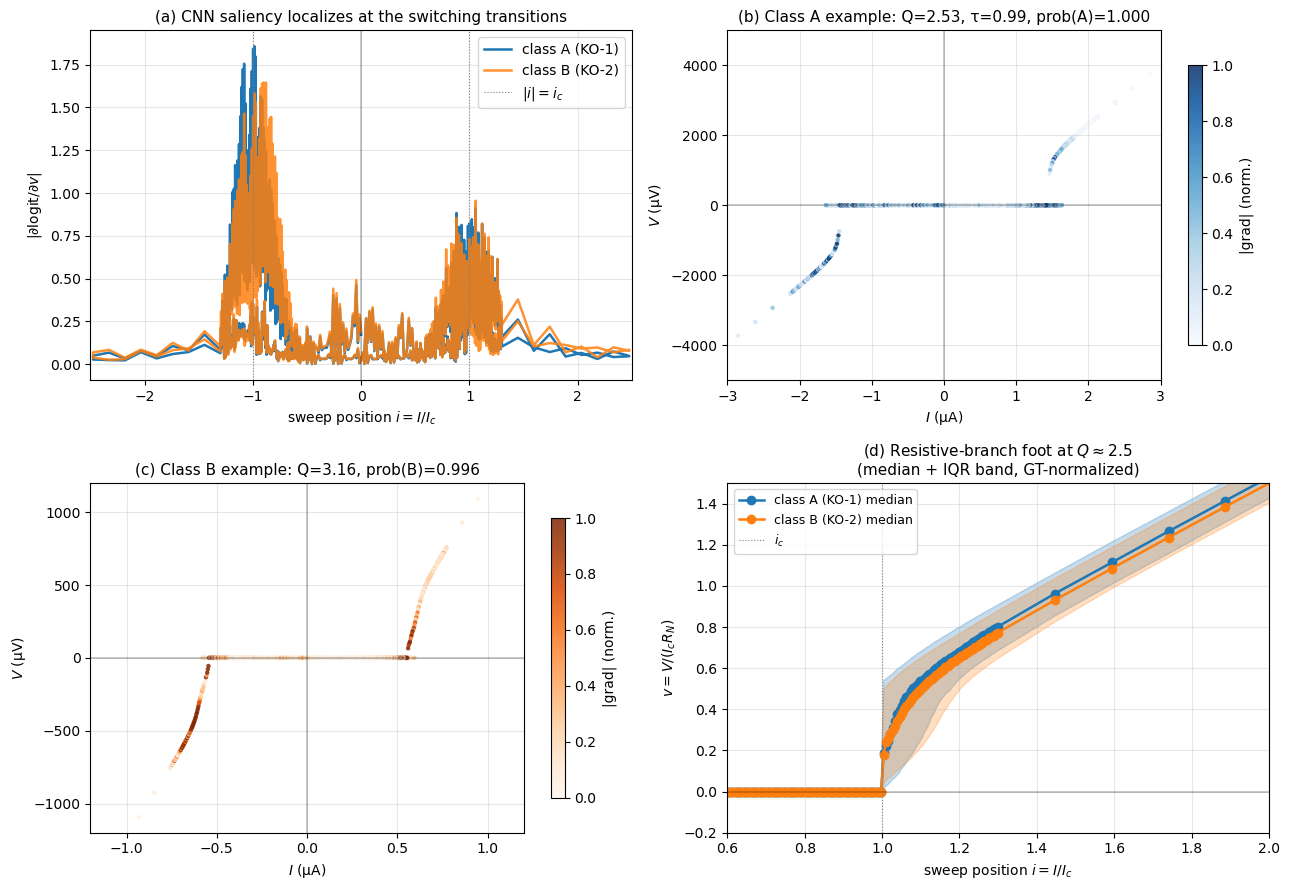

saved -> c:\Users\Frederik\Python\ML4P\Final Project\s_bal_difussive_high_tau_project\..\Fig\cnn_saliency_clean.png


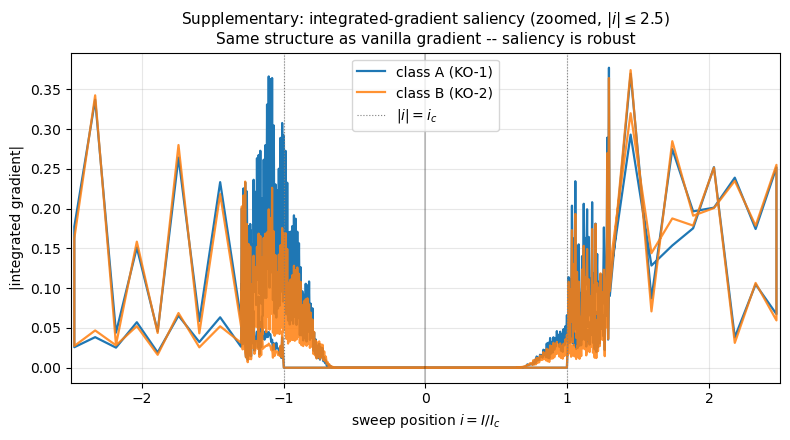

saved -> c:\Users\Frederik\Python\ML4P\Final Project\s_bal_difussive_high_tau_project\..\Fig\cnn_saliency_ig_supp.png


In [19]:
"""
Cell 6 (cleaned): saliency figure for the writeup.

Vanilla input-gradient saliency is the primary method (cleaner than IG).
IG is computed but saved to a supplementary figure for robustness.

Main figure layout (2x2):
  (a) Average |grad| vs sweep position, both classes (zoomed in around |i|=1).
  (b) IV curve for one class A example, points colored by |grad|.
  (c) IV curve for one class B example, points colored by |grad|.
  (d) Switching-transition zoom: average IV curves near +i_c for both classes
      (median + IQR band), showing that the foot shape genuinely differs.
"""
import time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ----- 1. Reload the saved saliency -----
saved = np.load(HERE / "cnn_saliency.npz")
ig_all     = saved["ig_all"]
vg_all     = saved["vg_all"]
y_all      = saved["y"]
sweep_dl   = saved["sweep_dimless"]

# Average |grad| per class
vg_mag_A = vg_all[y_all == 0].mean(axis=0)
vg_mag_B = vg_all[y_all == 1].mean(axis=0)


# ----- 2. Reload data and indices for the per-trace panels -----
data = np.load(HERE / "iv_dataset.npz", allow_pickle=False)
V       = data["V"].astype(np.float32)
I_data  = data["I"].astype(np.float32)
y       = data["y"].astype(np.int64)
params  = data["params"]
N, M = V.shape

idx_all = np.arange(N)
idx_tr, idx_tmp = train_test_split(idx_all, test_size=0.30, stratify=y,
                                    random_state=0)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50,
                                    stratify=y[idx_tmp], random_state=0)
y_te = y[idx_te]
V_te = V[idx_te]
I_te = I_data[idx_te]


# ----- 3. Reload model, recompute predictions for confidence ranking -----
class IVCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, 7, padding=3, stride=2),
                nn.BatchNorm1d(c_out, momentum=0.01),
                nn.GELU(),
                nn.Dropout(0.1),
            )
        self.net = nn.Sequential(block(1, 16), block(16, 32),
                                  block(32, 64), block(64, 64))
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(64, n_classes)
    def forward(self, x):
        h = self.net(x); h = self.pool(h).squeeze(-1); return self.head(h)


model = IVCNN(2).to(device)
model.load_state_dict(torch.load(HERE / "iv_cnn_best.pt", map_location=device))
model.eval()

V_mean_global = V[idx_tr].mean()
V_std_global  = V[idx_tr].std()
X_te = ((V_te - V_mean_global) / V_std_global).astype(np.float32)
X_te = X_te[:, np.newaxis, :]

with torch.no_grad():
    out = []
    for i in range(0, len(X_te), 256):
        xb = torch.from_numpy(X_te[i:i+256]).to(device)
        out.append(F.softmax(model(xb), dim=1).cpu().numpy())
prob_te = np.concatenate(out, axis=0)
pred_te = prob_te.argmax(axis=1)
correct = (pred_te == y_te)
conf    = prob_te.max(axis=1)


def top_correct(cls, k=1):
    mask = correct & (y_te == cls)
    idxs = np.where(mask)[0]
    return idxs[np.argsort(-conf[idxs])[:k]]


# ----- 4. Build the cleaned figure -----
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- Panel (a): saliency vs sweep position, ZOOMED on |i| <= 2.5 ---
ax = axes[0, 0]
mask_zoom = np.abs(sweep_dl) <= 2.5
ax.plot(sweep_dl[mask_zoom], vg_mag_A[mask_zoom],
        color='tab:blue', lw=1.8, label='class A (KO-1)')
ax.plot(sweep_dl[mask_zoom], vg_mag_B[mask_zoom],
        color='tab:orange', lw=1.8, label='class B (KO-2)', alpha=0.85)
ax.axvline( 1, color='gray', lw=0.8, linestyle=':',
            label=r'$|i|=i_c$')
ax.axvline(-1, color='gray', lw=0.8, linestyle=':')
ax.axvline(0, color='k', lw=0.3)
ax.set_xlabel(r"sweep position $i = I/I_c$")
ax.set_ylabel(r"$|\partial \mathrm{logit} / \partial v|$")
ax.set_title("(a) CNN saliency localizes at the switching transitions",
              fontsize=11)
ax.grid(alpha=0.3); ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(-2.5, 2.5)


# --- Panel (b): class A example trace, IV colored by |grad| ---
def plot_trace_with_saliency(ax, idx_in_te, cmap_name='Reds', title_prefix=''):
    """Plot IV curve with each point colored by saliency magnitude."""
    I_phys = I_te[idx_in_te]
    V_phys = V_te[idx_in_te]
    sal    = vg_all[idx_in_te]
    # Robust normalization: scale by 95th percentile to avoid being thrown by outliers
    sal_norm = sal / np.percentile(sal, 95)
    sal_norm = np.clip(sal_norm, 0, 1)
    sc = ax.scatter(I_phys, V_phys, c=sal_norm, cmap=cmap_name,
                    s=10, alpha=0.85, edgecolors='none',
                    vmin=0, vmax=1)
    ax.axhline(0, color='k', lw=0.3); ax.axvline(0, color='k', lw=0.3)
    ax.set_xlabel(r"$I$ (µA)"); ax.set_ylabel(r"$V$ (µV)")
    ###  x-lim range: ###
    ax.set_xlim(-3,3); ax.set_ylim(-5000, 5000)
    
    ax.grid(alpha=0.3)
    p = params[idx_te[idx_in_te]]
    true_cls = int(y_te[idx_in_te])  # true class is what we want to show prob for
    info = f"{title_prefix} Q={p['Q']:.2f}"
    if p['cpr'] == 1:
        info += f", τ={p['cpr_p']:.2f}"
    info += f", prob({SHORT[true_cls]})={prob_te[idx_in_te, true_cls]:.3f}"
    ax.set_title(info, fontsize=11)
    return sc

idx_A = top_correct(0, k=1)[0]
idx_B = top_correct(1, k=1)[0]

sc_A = plot_trace_with_saliency(axes[0, 1], idx_A, cmap_name='Blues',
                                  title_prefix='(b) Class A example:')
plt.colorbar(sc_A, ax=axes[0, 1], shrink=0.8, label='|grad| (norm.)')

sc_B = plot_trace_with_saliency(axes[1, 0], idx_B, cmap_name='Oranges',
                                  title_prefix='(c) Class B example:')
plt.colorbar(sc_B, ax=axes[1, 0], shrink=0.8, label='|grad| (norm.)')

###  y-lim range: ###
axes[1, 0].set_xlim(-1.2,1.2); axes[1, 0].set_ylim(-1200, 1200)

# --- Panel (d): switching-transition zoom, average shape per class ---
# Take the up-sweep leg (leg1: i from 0 to +i_max) and average V vs i
# (in dimensionless units) across all correctly classified test traces.
# We restrict to traces with similar Q for fairness.
ax = axes[1, 1]

# Find leg1 indices (up-sweep, 0 -> +i_max)
diffs = np.diff(sweep_dl)
turning = np.where(np.diff(np.sign(diffs)) != 0)[0] + 1
leg1_end = turning[0]
leg1_idx = np.arange(0, leg1_end + 1)
ax.set_ylim(-0.2, 1.5)

# Use dimensionless v = V / (I_c R_N)
Ic_te = params[idx_te]['Ic_uA']
RN_te = params[idx_te]['RN_Ohm']
V_dimless_te = V_te / (Ic_te[:, None] * RN_te[:, None])

# Filter to a narrow Q band so curve shapes are comparable
Q_te = params[idx_te]['Q']
Q_target = 2.5
Q_tol = 0.5
mask_Q = (np.abs(Q_te - Q_target) < Q_tol) & correct
mask_A = mask_Q & (y_te == 0)
mask_B = mask_Q & (y_te == 1)
print(f"  Panel (d): using {mask_A.sum()} class A and {mask_B.sum()} class B "
      f"correctly-classified traces with Q in [{Q_target-Q_tol}, {Q_target+Q_tol}]")

V_dim_A = V_dimless_te[mask_A][:, leg1_idx]
V_dim_B = V_dimless_te[mask_B][:, leg1_idx]
sweep_leg1 = sweep_dl[leg1_idx]

# Median + IQR band
medA = np.median(V_dim_A, axis=0); q1A = np.quantile(V_dim_A, 0.25, axis=0); q3A = np.quantile(V_dim_A, 0.75, axis=0)
medB = np.median(V_dim_B, axis=0); q1B = np.quantile(V_dim_B, 0.25, axis=0); q3B = np.quantile(V_dim_B, 0.75, axis=0)

ax.fill_between(sweep_leg1, q1A, q3A, color='tab:blue',   alpha=0.25)
ax.plot(sweep_leg1, medA, color='tab:blue',   lw=1.8, label='class A (KO-1) median', marker='o', linestyle='-')
ax.fill_between(sweep_leg1, q1B, q3B, color='tab:orange', alpha=0.25)
ax.plot(sweep_leg1, medB, color='tab:orange', lw=1.8, label='class B (KO-2) median', marker='o', linestyle='-')
ax.axvline(1, color='gray', lw=0.8, linestyle=':', label=r'$i_c$')
ax.axhline(0, color='k', lw=0.3); ax.axvline(0, color='k', lw=0.3)
ax.set_xlim(0.6, 2.0)
ax.set_xlabel(r"sweep position $i = I/I_c$")
ax.set_ylabel(r"$v = V / (I_c R_N)$") 
ax.set_title(f"(d) Resistive-branch foot at $Q\\approx{Q_target}$\n"
             "(median + IQR band, GT-normalized)", fontsize=11)
ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=9)

fig.tight_layout()
fig.savefig(HERE / "../Fig/cnn_saliency_clean.png", dpi=140, bbox_inches='tight')
plt.show()
print(f"saved -> {HERE / '../Fig/cnn_saliency_clean.png'}")


# ----- 5. Supplementary figure: IG comparison (kept separately) -----
fig2, ax = plt.subplots(figsize=(8, 4.5))
mask_zoom = np.abs(sweep_dl) <= 2.5
ig_mag_A = np.abs(ig_all[y_all == 0]).mean(axis=0)
ig_mag_B = np.abs(ig_all[y_all == 1]).mean(axis=0)
ax.plot(sweep_dl[mask_zoom], ig_mag_A[mask_zoom],
        color='tab:blue',   lw=1.6, label='class A (KO-1)')
ax.plot(sweep_dl[mask_zoom], ig_mag_B[mask_zoom],
        color='tab:orange', lw=1.6, label='class B (KO-2)', alpha=0.85)
ax.axvline( 1, color='gray', lw=0.8, linestyle=':', label=r'$|i|=i_c$')
ax.axvline(-1, color='gray', lw=0.8, linestyle=':')
ax.axvline(0, color='k', lw=0.3)
ax.set_xlabel(r"sweep position $i = I/I_c$")
ax.set_ylabel(r"|integrated gradient|")
ax.set_title("Supplementary: integrated-gradient saliency (zoomed, $|i| \\leq 2.5$)\n"
             "Same structure as vanilla gradient -- saliency is robust", fontsize=11)
ax.grid(alpha=0.3); ax.legend()
ax.set_xlim(-2.5, 2.5)
fig2.tight_layout()
fig2.savefig(HERE / "../Fig/cnn_saliency_ig_supp.png", dpi=140, bbox_inches='tight')
plt.show()
print(f"saved -> {HERE / '../Fig/cnn_saliency_ig_supp.png'}")